# Program - plot-var_2d_time_lev-cn_xy_flexible-TaiESM_hindcast

**Purpose**

read TaiESM hindcast data and make plots for time-level dimension, including contour, time series, and profiles.

**Content**
- read data: Read TaiESM hindcast data at a grid point (lat, lon) and selected time range 
- set characteristics for plots, such as time tick mark labels, color map, etc.
- plot time series (xy_series)
- plot profiles for N variables at one time step (xy_profile_Nv1t)
- plot profiles for 1 variable at multiple time step (xy_profile_1vNt)
- plot time-level cross section (cn_time_level)

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
March 2025

**Reference program:**
Thanks for chatGPT.


In [82]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

# Functions

## ----- read data -----

## select_region_ds

In [83]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="lat_lon", lat=lat, lon=lon)

#ds1_region

## lat_lon_weighted_avg

In [84]:
import xarray as xr
import numpy as np

def lat_lon_weighted_avg(ds: xr.Dataset, lat_name: str = 'lat', lon_name: str = 'lon') -> xr.Dataset:
    """
    Compute the latitude-weighted average of an xarray.Dataset over lat and lon dimensions,
    only for variables that have both lat and lon in their coordinates.
    
    Parameters:
    ds (xr.Dataset): Input dataset with latitude and longitude dimensions.
    lat_name (str): Name of the latitude coordinate in the dataset.
    lon_name (str): Name of the longitude coordinate in the dataset.
    
    Returns:
    xr.Dataset: Dataset with lat/lon dimensions averaged using latitude weighting.
    """
    # Select only numeric variables that have both lat and lon as dimensions
    valid_vars = {
        var: ds[var] for var in ds.data_vars
        if np.issubdtype(ds[var].dtype, np.number) and {lat_name, lon_name}.issubset(ds[var].dims)
    }
    
    if not valid_vars:
        raise ValueError("No valid variables found with both lat and lon dimensions.")
    
    ds = xr.Dataset(valid_vars, coords=ds.coords)
    
    # Convert latitudes to radians for weighting
    lat_rad = np.deg2rad(ds[lat_name])
    
    # Compute latitude weights (cosine of latitude)
    weights = np.cos(lat_rad)
    
    # Normalize weights only over lat dimension
    weights /= weights.sum(dim=lat_name)
    
    # Compute weighted mean using dot product for efficiency
    weighted_mean = ds.weighted(weights).mean(dim=[lat_name, lon_name])
    
    return weighted_mean


## read_hindcast_icdate_lat_lon

In [85]:
def assign_ds_attrs(ds: xr.Dataset,
                    region, lat_values, lon_values):
    ds = ds.assign_attrs(
        avg_region=region,
        avg_lat=lat_values,
        avg_lon=lon_values,
    )
    return ds

def read_hindcast_icdate_lat_lon(icdate, 
    icdata_option = "ERA5", 
    ss5="00000",
    region=None,
    lat=None, lon=None,
    ):

    file_dates = 5

    #--- read datasets
    choice = "custom_Ttend_3hr"
    ds_Ttend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_state_3hr"
    ds_state = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_Qtend_3hr"
    ds_Qtend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_2d_1hr"
    ds_2d = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    #--- diagnose variables in all ds
    yhc.diagnose_var(ds_state, ["play","plev","Z3_ilev"])
    yhc.diagnose_var(ds_Ttend, ["DT_SUM_PHYS", "DT_deep"])
    yhc.diagnose_var(ds_Qtend, ["DQV_SUM_PHYS", "DQL_SUM_PHYS", "DQV_deep", "DQV_SUM_PHYS_no_MA_VD", "DQL_SUM_PHYS_no_MA_VD" ])

    #--- get data at the given lat/lon
    ds_Ttend_latlon = select_region_ds(ds_Ttend, region=region, lat=lat, lon=lon)
    ds_Qtend_latlon = select_region_ds(ds_Qtend, region=region, lat=lat, lon=lon)
    ds_state_latlon = select_region_ds(ds_state, region=region, lat=lat, lon=lon)
    ds_1d_time_latlon = select_region_ds(ds_2d, region=region, lat=lat, lon=lon)

    lat_values = ds_state_latlon['lat'].values.tolist()
    lon_values = ds_state_latlon['lon'].values.tolist()

    if region != "lat_lon":        
        ds_state_latlon = lat_lon_weighted_avg(ds_state_latlon)
        ds_state_latlon = assign_ds_attrs(ds_state_latlon, region, lat_values, lon_values)
        ds_Ttend_latlon = lat_lon_weighted_avg(ds_Ttend_latlon)
        ds_Ttend_latlon = assign_ds_attrs(ds_Ttend_latlon, region, lat_values, lon_values)
        ds_Qtend_latlon = lat_lon_weighted_avg(ds_Qtend_latlon)
        ds_Qtend_latlon = assign_ds_attrs(ds_Qtend_latlon, region, lat_values, lon_values)
        ds_1d_time_latlon = lat_lon_weighted_avg(ds_1d_time_latlon)
        ds_1d_time_latlon = assign_ds_attrs(ds_1d_time_latlon, region, lat_values, lon_values)
    
    return ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    icdate = "20010707" ; ss5="00000"
    #icdate = "20010711" ; ss5="43200"

    #region = "DYCOMS"

    region = "lat_lon" ; lat=30 ; lon=240
    #ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate, region=region)
    icdata_option = "qq02_macrop_tpdf"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate, icdata_option=icdata_option, 
                                                                                                        region=region, lat=lat, lon=lon, ss5=ss5)

#ds_state_latlon
#ds_Ttend_latlon
#ds_Qtend_latlon
#ds_1d_time_latlon

#pp = yhc.get_area_avg(ds_state_latlon, region="DYCOMS")

## get_ds_time_level_2d_vars_for_xy_plot

In [86]:
import cftime

###############
###############
###############
class read_hindcast_data:
    def __init__(self, icdate, icdata_option="ERA5", ss5="00000", region=None, lat=None, lon=None):
        """
        Initialize the object with initial datasets based on the provided initial conditions (icdate), 
        latitude (lat), and longitude (lon).
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - icdata_option: Option for selecting hindcast data (string, default="ERA5")
        - region: Region identifier for the dataset (string, optional)
        - lat: Latitude coordinate for the data (float, optional)
        - lon: Longitude coordinate for the data (float, optional)
        """
        self.icdata_option = icdata_option  # Store the icdata_option
        self.region = region  # Store the region
        self.datasets = {}  # Store datasets in a dictionary
        self.load_data(icdate, lat, lon)  # Load initial datasets

    def load_data(self, icdate, lat, lon):
        """
        Load datasets dynamically using the given initial condition date, latitude, and longitude. 
        The datasets are retrieved and stored in the `self.datasets` dictionary.
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - lat: Latitude coordinate for the data (float)
        - lon: Longitude coordinate for the data (float)
        """
        try:
            # Retrieve data from the hindcast based on the given initial conditions
            ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(
                icdate, ss5=ss5, icdata_option=self.icdata_option, region=self.region, lat=lat, lon=lon,
            )
            
            # Store the datasets in the dictionary
            self.datasets["ds_state"] = ds_state_latlon  # Main state dataset
            self.datasets["ds_Ttend"] = ds_Ttend_latlon  # Temperature tendency dataset
            self.datasets["ds_Qtend"] = ds_Qtend_latlon  # Q tendency dataset
            self.datasets["ds_1d_time"] = ds_1d_time_latlon  # Q tendency dataset
            self.datasets["play"] = ds_state_latlon["play"]  # Play variable from state dataset
            self.datasets["Z3"] = ds_state_latlon["Z3"]  # Store "Z3" from state dataset
            self.datasets["plev"] = ds_state_latlon["plev"]  # Store "Z3" from state dataset
            self.datasets["Z3_ilev"] = ds_state_latlon["Z3_ilev"]  # Store "Z3" from state dataset

            # add new attributes
            self.datasets["play"].attrs["coord_label"] = "Pressure (hPa)"
            self.datasets["play"].attrs["do_inverse_yaxis"] = True
            self.datasets["plev"].attrs["coord_label"] = "Pressure (hPa)"
            self.datasets["plev"].attrs["do_inverse_yaxis"] = True
            
            self.datasets["Z3"].attrs["coord_label"] = "Altitude (m)"
            self.datasets["Z3"].attrs["do_inverse_yaxis"] = False
            self.datasets["Z3_ilev"].attrs["coord_label"] = "Altitude (m)"
            self.datasets["Z3_ilev"].attrs["do_inverse_yaxis"] = False
        
        except Exception as e:
            print(f"Error loading data: {e}")  # Error handling if data loading fails
            self.datasets = {}  # Reset the datasets in case of an error

    def get(self, data):
        """
        Retrieve a specific dataset by name.

        Args:
        - data: The name of the dataset to retrieve (string)
        
        Returns:
        - The requested dataset or None if the dataset is not found.
        """
        return self.datasets.get(data, None)

    def set(self, key, value):
        """
        Modify or add a dataset to the dictionary dynamically.

        Args:
        - key: The name of the dataset (string)
        - value: The dataset value (object)
        """
        self.datasets[key] = value  # Add or update the dataset in the dictionary

###############
###############
###############
def select_ds_time_period(ds_dict, lev_dict, start_str=None, end_str=None):
    """
    Selects data from a dictionary of xarray Datasets within a specified time period.

    Parameters:
        ds_dict (dict): A dictionary of xarray Datasets, where each dataset contains a 'time' coordinate in cftime.DatetimeNoLeap format.
        start_str (str): Start time in "YYYYMMDD_HHMMSS" format.
        end_str (str): End time in "YYYYMMDD_HHMMSS" format.

    Returns:
        dict: A dictionary of xarray Datasets within the specified time range.
    """

    # Assuming all datasets in ds_dict have the same time range, get the global time range from one of them
    time_min, time_max = ds_dict[next(iter(ds_dict))].time.min().item(), ds_dict[next(iter(ds_dict))].time.max().item()

    # Check if the start_str and end_str are provided
    if start_str:
        # Parse start time from "YYYYMMDD_HHMMSS" format
        start_time = cftime.DatetimeNoLeap(
            int(start_str[:4]),  # Year
            int(start_str[4:6]),  # Month
            int(start_str[6:8]),  # Day
            int(start_str[9:11]),  # Hour
            int(start_str[11:13]),  # Minute
            int(start_str[13:15])   # Second
        )

        # Validate start_time within dataset range
        if start_time < time_min or start_time > time_max:
            raise ValueError(f"start_str ({start_str}) is out of range: {time_min} to {time_max}")
    else:
        start_time = time_min  # Default to minimum time in dataset if start_str is not provided

    if end_str:
        # Parse end time from "YYYYMMDD_HHMMSS" format
        end_time = cftime.DatetimeNoLeap(
            int(end_str[:4]),  # Year
            int(end_str[4:6]),  # Month
            int(end_str[6:8]),  # Day
            int(end_str[9:11]),  # Hour
            int(end_str[11:13]),  # Minute
            int(end_str[13:15])   # Second
        )

        # Validate end_time within dataset range
        if end_time < time_min or end_time > time_max:
            raise ValueError(f"end_str ({end_str}) is out of range: {time_min} to {time_max}")
    else:
        end_time = time_max  # Default to maximum time in dataset if end_str is not provided

   # Check if end_time is greater than start_time
    if end_time < start_time:
        raise ValueError(f"end_time ({end_time}) cannot be earlier than start_time ({start_time})")
        
    # Apply the time selection to each dataset in the dictionary and return the updated dictionary
    ds_dict_filtered = {key: ds.sel(time=slice(start_time, end_time)) for key, ds in ds_dict.items()}
    lev_dict_filtered = {key: lev.sel(time=slice(start_time, end_time)) for key, lev in lev_dict.items()}

    return ds_dict_filtered, lev_dict_filtered

###############
###############
###############
def select_lev_range_old(ds_dict, lev_dict, lev_select=None, lev_min=None, lev_max=None):
    """
    Filters datasets within a specified lev range based on a selected variable from lev_dict.

    Parameters:
        ds_dict (dict): Dictionary containing the datasets (e.g., 'ds_state', 'ds_Ttend').
        lev_dict (dict): Dictionary containing the variables like 'play', 'Z3'.
        lev_select (str): Select which variable from lev_dict to use ('play' or 'Z3').
        lev_min (float): Minimum lev value for filtering.
        lev_max (float): Maximum lev value for filtering.

    Returns:
        tuple: Filtered ds_dict and lev_dict.
    """

    if lev_min is not None and lev_max is not None:
        # Check which variable to use for filtering
        if lev_select == "pressure":
            mask_lev = (lev_dict["play"] > lev_min) & (lev_dict["play"] < lev_max)
            mask_ilev = (lev_dict["plev"] > lev_min) & (lev_dict["plev"] < lev_max)

        elif lev_select == "play":
            mask = (lev_dict["play"] > lev_min) & (lev_dict["play"] < lev_max)
        elif lev_select == "plev":
            mask = (lev_dict["plev"] > lev_min) & (lev_dict["plev"] < lev_max)
        elif lev_select == "Z3":
            mask = (lev_dict["Z3"] > lev_min) & (lev_dict["Z3"] < lev_max)
        elif lev_select == "Z3_ilev":
            mask = (lev_dict["Z3_ilev"] > lev_min) & (lev_dict["Z3_ilev"] < lev_max)
        else:
            raise ValueError(f"Invalid lev_select value: {lev_select}. Must be ('play', 'plev', 'Z3', 'Z3_ilev'")
        
        # Compute the mask if it's a dask array
        mask_lev_computed  = mask_lev.compute()  # Eager evaluation
        lev_indices = mask_lev_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values

        # Compute the mask if it's a dask array
        mask_ilev_computed  = mask_ilev.compute()  # Eager evaluation
        ilev_indices = mask_ilev_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        ilev_values_to_select = lev_dict["plev"].ilev.values[ilev_indices]  # Get lev values

        lev_dict_filtered = {
            key: (
                val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" 
                else val.sel(ilev=lev_values_to_select) if key == "plev" or key == "Z3_ilev" 
                else val
            )
            for key, val in lev_dict.items()
                            }
            #print(ds_dict.items

        ds_dict_filtered = ds_dict.copy()
        
        if lev_select == "play" or lev_select == "Z3":
            lev_indices = mask_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
            lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values from play or Z3

            ds_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in ds_dict.items()}
            lev_dict_filtered = {
                key: (
                    val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" 
                    else val.sel(ilev=ilev_values_to_select) if key == "plev" or key == "Z3_ilev" 
                    else val
                )
                for key, val in lev_dict.items()
                                }
            #lev_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in lev_dict.items()}   
            #lev_dict_filtered = {key: (val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" else val) for key, val in lev_dict.items()}
            
            #ds_dict_filtered = ds_dict.copy()
            #lev_dict_filtered = lev_dict.copy()
        
        # Get lev indices where the condition is True across all time points
        #if lev_select == "play" or lev_select == "Z3":
         #   lev_indices = mask_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        #lev_indices 
        
        # Extract the lev values that match the condition
        #lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values from play or Z3
        #ilev_values_to_select = lev_dict["plev"].ilev.values[ilev_indices]  # Get lev values from play or Z3
    
        # Apply filtering to the datasets using the lev values
        #if lev_select == "play" or lev_select == "Z3":
        #    ds_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in ds_dict.items()}
        #    lev_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in lev_dict.items()}
        #elif lev_select == "plev" or lev_select == "Z3_ilev":
        #    ds_dict_filtered = {key: val.sel(ilev=ilev_values_to_select) for key, val in ds_dict.items()}
        #    lev_dict_filtered = {key: val.sel(ilev=ilev_values_to_select) for key, val in lev_dict.items()}
        
        return ds_dict_filtered, lev_dict_filtered
    else:
        return ds_dict, lev_dict

###############
###############
###############
def select_lev_range(ds_dict, lev_dict, lev_select=None, lev_coord='lev', lev_min=None, lev_max=None):
    """
    Filters datasets within a specified lev range based on a selected variable from lev_dict.

    Parameters:
        ds_dict (dict): Dictionary containing the datasets (e.g., 'ds_state', 'ds_Ttend').
        lev_dict (dict): Dictionary containing the variables like 'play', 'Z3'.
        lev_select (str): Select which variable from lev_dict to use ('play' or 'Z3').
        lev_coord (str): The coordinate to filter on, either 'lev' or 'ilev'.
        lev_min (float): Minimum lev value for filtering.
        lev_max (float): Maximum lev value for filtering.

    Returns:
        tuple: Filtered ds_dict and lev_dict.
    """

    if lev_min is not None and lev_max is not None:
        # Check if lev_select exists in lev_dict
        if lev_select not in lev_dict:
            raise ValueError(f"Selected variable {lev_select} is not present in lev_dict.")
        
        # Check if the selected coordinate exists in lev_dict[lev_select]
        if lev_coord not in lev_dict[lev_select].coords:
            raise ValueError(f"Coordinate '{lev_coord}' is not present in the selected variable '{lev_select}'.")

        # Get lev values
        lev_values = lev_dict[lev_select].values

        # Apply the mask to get a boolean array (time, lev or ilev)
        mask = (lev_values > lev_min) & (lev_values < lev_max)

        # Reduce across the time dimension to find the valid levels
        lev_indices_to_select = np.any(mask, axis=0)  # Boolean array for each lev dimension
        selected_lev_indices = np.where(lev_indices_to_select)[0]  # Indices of levs that pass the condition

        # Filter datasets, only if they have the specified lev_coord dimension
        ds_dict_filtered = {
            key: (val.isel({lev_coord: selected_lev_indices}) if lev_coord in val.dims else val) 
            for key, val in ds_dict.items()
        }

        # Filter lev_dict similarly
        lev_dict_filtered = {
            key: (val.isel({lev_coord: selected_lev_indices}) if lev_coord in val.dims else val) 
            for key, val in lev_dict.items()
        }

        return ds_dict_filtered, lev_dict_filtered

    else:
        return ds_dict, lev_dict

###############
###############
###############
def get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option="ERA5",
                                          ss5="00000", 
                                          region=None, lat=None, lon=None,
                                         lev_select=None, lev_min=None, lev_max=None,
                                         start_str=None, end_str=None,
                                         ):
    """
    Retrieve datasets containing variables with 2D dimensions [time, level] for use in XY plots.
    The function returns datasets for key variables such as state, Ttend, Qtend, and other related variables 
    like play and Z3.

    Args:
    - icdate: The initial condition date for the hindcast (string or datetime)
    - lat: Latitude coordinate for the data (float)
    - lon: Longitude coordinate for the data (float)

    Returns:
    - ds_dict: Dictionary containing the primary datasets (state, Ttend, Qtend)
    - lev_dict: Dictionary containing additional variables for XY plot (play, Z3)
    """

    func_name = "get_ds_time_level_2d_vars_for_xy_plot"
    
    # Create an instance of the read_hindcast_data class
    hindcast_data = read_hindcast_data(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon)

    # Retrieve the datasets for main variables
    ds_dict = {
        "state": hindcast_data.get("ds_state"),  # Main state dataset
        "Ttend": hindcast_data.get("ds_Ttend"),  # Temperature tendency dataset
        "Qtend": hindcast_data.get("ds_Qtend"),  # Q tendency dataset
        "1d_time": hindcast_data.get("ds_1d_time"),  # time series dataset
    }

    # Additional variables for XY plot
    lev_dict = {
        "play": hindcast_data.get("play"),  # Play variable for plotting
        "plev": hindcast_data.get("plev"),  # Play variable for plotting
        "Z3": hindcast_data.get("Z3"),  # Z3 variable for plotting
        "Z3_ilev": hindcast_data.get("Z3_ilev"),  # Z3 variable for plotting

    }

    # select level range
    if (lev_select == "play"):
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "play", lev_coord="lev", lev_min=lev_min, lev_max=lev_max)
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "plev", lev_coord="ilev", lev_min=lev_min, lev_max=lev_max)
    elif (lev_select == "Z3"):
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "Z3", lev_coord="lev", lev_min=lev_min, lev_max=lev_max)
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "Z3_ilev", lev_coord="ilev", lev_min=lev_min, lev_max=lev_max)        
    elif (lev_select is None):
        pass
    else:
        raise ValueError(f"[{func_name}]: Invalid lev_select value: {lev_select}. Must be 'play' or 'Z3'.")
    
    # select time range
    ds_dict, lev_dict = select_ds_time_period(ds_dict, lev_dict, start_str=start_str, end_str=end_str)

    return ds_dict, lev_dict

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    #icdate = "20010711" ; ss5="43200"
    icdate = "20010707" ; ss5="00000"

    #region="lat_lon" ; lat = 31.5 ; lon = 236.5
    region = "DYCOMS"
    icdata_option = "qq02_macrop_park"
    
    # select all time and lev
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, region=region, lat=lat, lon=lon)

    # select lev range
    lev_select = "Z3" ; lev_max = 3000 ; lev_min = 1000
    #lev_select = "play" ; lev_max = 1000 ; lev_min = 500
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

    # select time range
    #start_str = "20010711_000000"
    #end_str = "20010713_000000"
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
    #                                                         start_str=start_str, end_str=end_str)

    # select both time and lev range
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
    #                                                         lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
    #                                                         start_str=start_str, end_str=end_str)

#ds_dict['Qtend']
#ds_dict['1d_time']
#print(ds_dict['state'])
#lev_dict
#lev_dict['play']
#lev_dict.items()



## ----- shared for cn and xy plots -----

## create_time_coord_labels

In [87]:
import numpy as np
import pandas as pd
import cftime
import warnings

def create_time_coord_labels(ds, time_interval, time_vert_lines=None):

    func_name = "create_time_coord_labels"
    
    # Convert cftime.DatetimeNoLeap to numpy datetime64 for better compatibility
    ds_times = np.array([np.datetime64(pd.Timestamp(t.year, t.month, t.day, t.hour, t.minute, t.second)) for t in ds["time"].values])

    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds_times))

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval)
    time_labels = [pd.Timestamp(t).strftime('%m%d_%H') for t in ds_times[time_ticks]]

    # Process time_vert_lines if provided
    time_numeric_vert_lines = []
    if time_vert_lines:
        time_vert_lines_dt = np.array(pd.to_datetime(time_vert_lines, format='%Y%m%d_%H%M%S').to_numpy(), dtype='datetime64[ns]')

        for t in time_vert_lines_dt:
            # Check if t is within the dataset's time range
            if t < ds_times[0] or t > ds_times[-1]:
                warnings.warn(f"Warning [func {func_name}]: Time {t} is outside the dataset time range ({ds_times[0]} to {ds_times[-1]}). Skip to plot lines at t.", UserWarning)
                continue  # Skip this time
            
            idx = np.argmin(np.abs(ds_times - t))  # Find the closest index
            time_numeric_vert_lines.append(idx)

    return time_numeric, time_ticks, time_labels, time_numeric_vert_lines


time_interval = 3
time_vert_lines = ["20050711_120000", "20050711_060000"]
#time_numeric, time_ticks, time_label, time_numeric_vert_lines = create_time_coord_labels(ds_dict['state'], 
#                                                                                         time_interval=time_interval,
#                                                                                         time_vert_lines=time_vert_lines)
#print(time_numeric)
#print(time_ticks)
#print(time_label)
#print(time_numeric_vert_lines)

## generate_plot_xy_kwargs

In [131]:
################
################
################
def separate_var_dict(var_dict, default_style):
    """
    Separates the variable dictionary into two dictionaries:
    - One containing plot styling attributes ('color', 'marker', 'linestyle').
    - One containing other attributes (e.g., 'label').

    If 'color', 'marker', or 'linestyle' are missing, default values are assigned.

    Parameters:
    var_dict (dict): Dictionary mapping variable names to their plotting attributes.

    Returns:
    tuple: (dict with styling attributes, dict with other attributes)
    """
    style_keys = {'color', 'marker', 'linestyle'}  # Keys related to plot styles
    
    # Default style settings
    #default_style = {
    #    'color': 'blue',     # Default color
    #    'marker': 'x',        # Default marker
    #    'linestyle': '-'      # Default linestyle
    #}
    
    style_dict = {}  # Dictionary for color, marker, linestyle
    meta_dict = {}   # Dictionary for other attributes

    for var, attrs in var_dict.items():
        # Extract style-related attributes and apply defaults where necessary
        style_dict[var] = {k: attrs.get(k, default_style[k]) for k in style_keys}
        
        # Extract metadata attributes (anything not in style_keys)
        meta_dict[var] = {k: v for k, v in attrs.items() if k not in style_keys}

    return style_dict, meta_dict

################
################
################
def generate_plot_xy_kwargs(var_name, da, var_list, option_default=None):
    """
    Generate plot styling and metadata dictionaries for a given variable.
    
    Parameters:
    var_name (str): The primary variable name.
    da (xarray.DataArray): DataArray object to extract metadata.
    var_list (list): List of variable names.
    
    Returns:
    tuple: (style_dict, meta_dict) for the given var_name.
    """

    # Define colors for different processes
    #  
    #    * Line colors, https://matplotlib.org/stable/gallery/color/named_colors.html
    #        red (r), blue (b), green (g), cyan (c), magenta (m), yellow (y), black (k), white (w)
    #
    #.   * Line dash pattern, https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
    #.       {'-', '--', '-.', ':'} {solid, dashed, dashdot, dotted}
    #
    #.   * Markers, https://matplotlib.org/stable/api/markers_api.html
    #        {'.', 'o', '^', 's'} = {point, circle, triangle_up, square}  

    color_tot = 'black' ; color_dyn = 'darkgray' ; color_PT = 'red' ; color_sum = color_PT
    color_ZM = 'blue'   ; color_CMF = 'cyan'     ; color_DPDLF = 'royalblue' ; color_SHDLF = 'skyblue'
    color_MACP = 'green' ; color_MP = 'limegreen' ; color_QRL = 'orange' ; color_QRS = 'pink' 
    color_vdiff = 'purple' ; color_gwd = 'yellow'
    
    color_cyan = 'c' ; color_red = 'r' 
    
    # Define style and metadata information
    var_dict = {
        #--- T tendency 
        'TTEND_TOT': {'color': color_tot, 'label': 'Total=dyn+phys [TTEND_TOT]'},
        'DTCORE': {'color': color_dyn, 'label': 'Dynamics [DTCORE]'},
        'PTTEND': {'color': color_PT, 'label': 'All phys [PTTEND]'},
        'DT_deep': {'color': color_ZM, 'label': 'Deep convection [ZMDT+ZMMTT+EVAPTZM]'},
        'CMFDT': {'color': color_CMF, 'label': 'Shallow convection [CMFDT]'},
        'DPDLFT': {'color': color_DPDLF, 'label': 'Deep conv detrain [DPDLFT]'},
        'SHDLFT': {'color': color_SHDLF, 'label': 'Shallow conv detrain [SHDLFT]'},
        'MACPDT': {'color': color_MACP, 'label': 'Macrophysics [MACPDT]'},
        'MPDT': {'color': color_MP, 'label': 'Microphysics [MPCT]'},
        'QRL': {'color': color_QRL, 'label': 'LW radiation [QRL]'},
        'QRS': {'color': color_QRS, 'label': 'SW radiation [QRS]'},
        'DTV': {'color': color_vdiff, 'label': 'PBL & turbulence [DTV]'},
        'TTGWORO': {'color': color_gwd, 'label': 'grav wave drag [TTGWORO]'},
        'DT_SUM_PHYS': {'color': color_sum, 'label': 'Sum of all phys tend', 'linestyle': '--'},

        #--- QV tendency 
        #'QVTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QVTEND_TOT]'},
        #'DQVCORE': {'color':color_dyn, 'label': 'Dynamics [DQVCORE]'},
        #'PTEQ': {'color':color_PT, 'label': 'All phys [PTEQ]'},

        'QVTEND_TOT': {'color':color_tot, 'label': 'dyn+phys'},
        'DQVCORE': {'color':color_dyn, 'label': 'dyn'},
        'PTEQ': {'color':color_PT, 'label': 'all phys'},
        'MACPDQ': {'color':color_MACP, 'label':'macro'},
        'VD01': {'color':color_vdiff, 'label': 'turb'},
        'DQV_SUM_PHYS_no_MA_VD': {'color':color_SHDLF, 'label': 'other phys'},
        
        'DQV_deep': {'color': color_ZM, 'label':'Deep convection [ZMDQ+EVAPQZM]'},
        'ZMDQ': {'color': color_ZM, 'label':'Deep convection [ZMDQ]'},
        'EVAPQZM': {'color': color_ZM, 'label':'Evap from deep conv [EVAPQZM]', 'linestyle': '--'},
        'CMFDQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        #'MACPDQ': {'color':color_MACP, 'label':'Macrophysics [MACPDQ]'},
        'MPDQ': {'color':color_MP, 'label':'Microphysics [MPDQ]'},
        #'VD01': {'color':color_vdiff, 'label': 'PBL & turbulence [VD01]'},
        'DQV_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QL tendency 
        'QLTEND_TOT': {'color':color_tot, 'label': 'dyn+phys'},
        'DQLCORE': {'color':color_dyn, 'label': 'dyn'},
        'PTECLDLIQ': {'color':color_PT, 'label': 'all phys'},
        'MACPDLIQ': {'color':color_MACP, 'label':'macro'},
        'VDCLDLIQ': {'color':color_vdiff, 'label': 'turb'},
        'DQL_SUM_PHYS_no_MA_VD': {'color':color_SHDLF, 'label': 'other phys'},

        #'QLTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QLTEND_TOT]'},
        #'DQLCORE': {'color':color_dyn, 'label': 'Dynamics [DQLCORE]'},
        #'PTECLDLIQ': {'color':color_PT, 'label': 'All phys [PTECLDLIQ]'},
        'ZMDLIQ': {'color': color_ZM, 'label':'Deep convection [ZMDLIQ]'},
        'CMFDLIQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        'DPDLFLIQ': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFLIQ]'},
        'SHDLFLIQ': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFLIQ]'},
        #'MACPDLIQ': {'color':color_MACP, 'label':'Macrophysics [MACPDLIQ]'},
        'MPDLIQ': {'color':color_MP, 'label':'Microphysics [MPDLIQ]'},
        #'VDCLDLIQ': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDLIQ]'},
        'DQL_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QI tendency
        'QITEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QITEND_TOT]'},
        'DQICORE': {'color':color_dyn, 'label': 'Dynamics [DQICORE]'},
        'PTECLDICE': {'color':color_PT, 'label': 'All phys [PTECLDICE]'},
        'ZMDICE': {'color': color_ZM, 'label':'Deep convection [ZMDICE]'},
        'CMFDICE': {'color': color_CMF, 'label': 'Shallow convection [CMFDICE]'},
        'DPDLFICE': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFICE]'},
        'SHDLFICE': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFICE]'},
        'MACPDICE': {'color':color_MACP, 'label':'Macrophysics [MACPDICE]'},
        'MPDICE': {'color':color_MP, 'label':'Microphysics [MPDICE]'},
        'VDCLDICE': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDICE]'},
        'DQI_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},
        
        #--- precipitation
        'PRECC': {'color': 'b', 'label': 'Convective precip'},
        'PRECL': {'color': 'c', 'label': 'Large-scale precip'},

         #--- cloud fraction
        'CLDTOT': {'color': 'gray', 'label': 'Total cloud'},
        'CLDHGH': {'color': 'purple', 'label': ' High cloud'},
        'CLDMED': {'color': 'blue', 'label': ' Middle cloud'},
        'CLDLOW': {'color': 'limegreen', 'label': ' Low cloud'},    

         #--- cloud radiative effects
        'LWCF': {'color': color_QRL},
        'SWCF': {'color': color_QRS},

        #--- cloud water path
        'TGCLDLWP': {'color': 'blue', 'label': 'Liquid water path'},
        'TGCLDIWP': {'color': 'cyan', 'label': 'Ice water path'},

        #--- surface fluxes
        'LHFLX': {'color': 'cyan'},
        'SHFLX': {'color': 'orange'},   
    }

    # Default style for unknown variables
    if (option_default == "xy_profile_1tNv"):
        default_style = {'color': 'blue', 'marker': '.', 'linestyle': '-'}
    elif (option_default == "xy_profile_1vNt"):
        default_style = {'color': 'blue', 'marker': '.', 'linestyle': '-'}
    else:
        default_style = {'color': 'blue', 'marker': None, 'linestyle': '-'}

    # Extract metadata from DataArray
    long_name = getattr(da, "long_name", None)
    units = getattr(da, "units", None)
    
    # Determine xlabel based on the number of variables
    if len(var_list) == 1:
        var_label = f"{long_name} ({units})" if long_name and units else long_name or units or var_name
    elif isinstance(var_list, str):
        var_label = f"{long_name} ({units})" if long_name and units else long_name or units or var_name
    else:
        var_label = units if units else var_name  # Ensure var_label is always assigned
    
    # Default metadata
    default_meta = {'label': var_name, 'var_label': var_label}

    # Separate style and metadata attributes
    style_dict, meta_dict = separate_var_dict(var_dict, default_style)

    # Retrieve style and metadata for the given var_name
    style = style_dict.get(var_name, default_style)
    meta = meta_dict.get(var_name, default_meta)

    # Ensure xlabel is included in the meta_dict
    meta['var_label'] = var_label
    if 'label' not in meta:
        meta['label'] = var_name  # Ensure 'label' is always present in meta

    return style, meta

## generate_cn_kwargs

In [89]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

################
################
################
def generate_cn_kwargs(var: xr.DataArray, var_name: str, user_settings=None):
    """
    Get plot settings (cmap, levels, long_name, units, and cbar_label) for a given variable.

    Parameters:
    - var: xarray.DataArray
        The variable to be plotted.
    - var_name: str
        The name of the variable.

    Returns:
    - settings: dict
        A dictionary with plot settings for the given variable.
    """
    # Default settings in case attributes are missing
    default_settings = {
        "cmap": "viridis",
        "levels": None,  # Will be determined dynamically if possible
        "norm": None, 
        "norm_option": "boundary", # use "boundary" so the levels can be activated using pcolormesh
        "long_name": var_name,  # Use var_name if long_name is missing
        "units": "Unknown Units",
        "cbar_label": f"{var_name} (Unknown Units)"
    }

    # Predefined variable settings (can be extended)
    ttend_min = -15 ; ttend_max = 15 ; ttend_num_levels = 31 ; ttend_int = 3
    variable_settings = {
        "TTEND_TOT": {"cmap": "RdBu_r", 
                      #"levels":np.linspace(ttend_min, ttend_max, ttend_num_levels) ,
                      "levels": np.arange(ttend_min, ttend_max + ttend_int, ttend_int),
                      #"norm": mcolors.TwoSlopeNorm(vmin=ttend_min, vcenter=0, vmax=ttend_max),
                      "norm_option" : "auto", 
                     },
        "QVTEND_TOT": {"cmap": "BrBG", 
                       "norm_option" : "auto", 
                      },
        "QLTEND_TOT": {"cmap": "PuOr", 
                       "norm_option" : "auto", 
                      },
        "T": {"cmap": "coolwarm"},
        "Q": {"cmap": "YlGnBu"},
        "CLDLIQ": {"cmap": "GnBu"},
        "P": {"cmap": "RdBu"}
    }

    # Merge additional_settings with the existing variable_settings
    #if user_settings:
    #    variable_settings.update(user_settings)

    # Extract attributes
    long_name = var.attrs.get("long_name", default_settings["long_name"])
    units = var.attrs.get("units", default_settings["units"])
    
    # Define variable groups for mapping
    TTEND_TOT_vars = ["MPDT", "MACPDT", "DTV", "DT_SUM_PHYS", "DTCORE", "PTTEND"]
    QVTEND_TOT_vars = ["PTEQ", "MACPDQ", "MPDQ", "VD01", "DQVCORE", "DQV_SUM_PHYS"]
    QLTEND_TOT_vars = ["PTECLDLIQ", "MACPDLIQ", "MPDLIQ", "VDCLDLIQ", "DQLCORE", "DQL_SUM_PHYS"]
    
    # Function to get the base variable name
    def get_base_var_name(var_name):
        if var_name in TTEND_TOT_vars:
            return "TTEND_TOT"
        elif var_name in QVTEND_TOT_vars:
            return "QVTEND_TOT"
        elif var_name in QLTEND_TOT_vars:
            return "QLTEND_TOT"
        else:
            return var_name  # Default to itself if no mapping exists
    
    # Merge additional_settings with the existing variable_settings
    if user_settings:
        for key, settings in user_settings.items():
            # For each key in user_settings, update only the provided fields, preserving others
            if key in variable_settings:
                variable_settings[key].update(settings)
            else:
                variable_settings[key] = settings

    # First, check if var_name has a user-defined setting
    if var_name in variable_settings:
        cmap, levels, norm = get_cmap_levels_norm(var_name, variable_settings, default_settings, var)
    else:
        # Determine cmap, levels, and norm
        base_var_name = get_base_var_name(var_name)
        cmap, levels, norm = get_cmap_levels_norm(base_var_name, variable_settings, default_settings, var)
        
    # Construct colorbar label
    cbar_label = f"{long_name} ({units})"

    return {
        "norm":norm, 
        ###
        "cmap": cmap,
        "levels": levels,
        "long_name": long_name,
        "units": units,
        "cbar_label": cbar_label
    }

################
################
################
def get_nice_contour_levels(var_data, num_levels=15):
    if np.issubdtype(var_data.dtype, np.number):  # Ensure it's numeric
        vmin, vmax = np.nanmin(var_data), np.nanmax(var_data)

        # Round vmin/vmax based on magnitude
        magnitude = 10 ** np.floor(np.log10(vmax - vmin))  # Order of magnitude
        vmin = np.floor(vmin / magnitude) * magnitude
        vmax = np.ceil(vmax / magnitude) * magnitude

        # Use MaxNLocator to find nice levels
        locator = mticker.MaxNLocator(nbins=num_levels - 1, steps=[1, 2, 2.5, 5, 10])
        levels = locator.tick_values(vmin, vmax)
    else:
        levels = default_settings["levels"]  # Use default if non-numeric

    return levels

################
################
################
def get_cmap_levels_norm(var_name, variable_settings, default_settings, var=None):
    """
    Retrieve colormap, contour levels, and norm settings for a given variable.

    Parameters:
        var_name (str): Name of the variable.
        variable_settings (dict): Dictionary with variable-specific settings.
        default_settings (dict): Dictionary with default settings.
        var (xarray.DataArray or numpy array, optional): Data array for computing levels dynamically.

    Returns:
        tuple: (cmap, levels, norm)
    """
    # Determine colormap
    cmap = variable_settings.get(var_name, {}).get("cmap", default_settings["cmap"])
    
    # Determine contour levels
    levels = variable_settings.get(var_name, {}).get("levels", default_settings["levels"])
    if levels is None and var is not None:
        var_data = var.values
        levels = get_nice_contour_levels(var_data)

    # Determine norm
    norm_option = variable_settings.get(var_name, {}).get("norm_option", default_settings["norm_option"])
    if norm_option == "auto":
        norm = mcolors.TwoSlopeNorm(vmin=np.min(levels), vcenter=0, vmax=np.max(levels))

    elif norm_option == "boundary":
        cmap_discrete = plt.get_cmap(cmap)  # Use discrete colors
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_discrete.N, extend="both")
        
    else:
        norm = variable_settings.get(var_name, {}).get("norm", default_settings["norm"])

    return cmap, levels, norm

## get_plot_opt

In [90]:
# Default values
opt_default_values = {
    "lev_select": "play", "lev_min": None, "lev_max": None,
    "start_str": None, "end_str": None, 
    "title": None, 

    #--- for cn_time_lev and xy_series plots
    "time_tick_major_interval":8, "time_tick_minor_number":3 ,
    "time_vert_lines": None, 

    #--- for xy_profile_1vNt plots
    "stride": 8, 

    #--- for xy_series_Nv plots
    "time_interval":1
}

#################
def get_opt_values(opt, defaults):
    return {key: opt.get(key, defaults[key]) for key in defaults}

#################
def get_plot_opt(opt_in):
    opt_out = get_opt_values(opt_in, opt_default_values)
    return opt_out

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    opt_in = {
        "lev_min": 800,
        "lev_max": 1000,
        "time_tick_major_interval": 100
    }    

    opt_out = get_plot_opt(opt_in)
    print(opt_out)
    #print(opt_out['lev_min'])

## add_labels_to_subplots

In [227]:
import string

def add_labels_to_subplots(axes, num_labels=20, fontsize=8):
    # Generate labels from "(a)" to the specified number of labels
    labels = [f"({char})" for char in string.ascii_lowercase[:num_labels]]  

    for i, ax in enumerate(axes):
        if i < len(labels):  # Ensure we don't exceed the number of labels
            ax.text(0, 1.15, labels[i], transform=ax.transAxes, fontsize=10, verticalalignment='top')

## get_time_indices_from_strings

In [109]:
import cftime
import numpy as np
import xarray as xr
from typing import List, Union

def get_time_indices_from_strings(
    data: Union[xr.Dataset, xr.DataArray],
    time_strs: List[str],
    time_dim: str = "time"
) -> List[int]:
    """
    Given an xarray Dataset or DataArray and a list of time strings in the format 'YYYYMMDD_HHMMSS',
    return the indices of matching times in the dataset's time coordinate.

    Parameters:
        data (xr.Dataset or xr.DataArray): Input dataset or dataarray.
        time_strs (List[str]): List of time strings in 'YYYYMMDD_HHMMSS' format.
        time_dim (str): Name of the time dimension (default is "time").

    Returns:
        List[int]: Indices of the matching times.
    """
    # Convert time strings to cftime.DatetimeNoLeap objects
    target_times = [
        cftime.DatetimeNoLeap(
            int(s[:4]), int(s[4:6]), int(s[6:8]),
            int(s[9:11]), int(s[11:13]), int(s[13:15]),
            has_year_zero=True
        ) for s in time_strs
    ]

    ds_times = data[time_dim].values
    indices = []

    for t_str, t_obj in zip(time_strs, target_times):
        if t_obj in ds_times:
            idx = np.where(ds_times == t_obj)[0][0]
            indices.append(idx)
        else:
            print(f"Warning: Time '{t_str}' not found in {time_dim} coordinate.")

    return indices

## (Not used) plot_xy_figs_panel

In [92]:
def plot_xy_figs_panel (ds_dict, lev_dict, var_src_names, option, 
                        time_interval=1, # input arguments for option="xy_series_Nv"
                        play_pt=None, date_selected=None, 
                        title=None):
    """
    Creates a panel plot with 2 columns and adjusts rows dynamically based on var_src_names.

    Parameters:
        ds_dict (dict): Dictionary containing dataset objects with keys as dataset names.
        var_src_names (list): List of tuples (dataset_key, variable_name) to plot.
        play_pt: Additional parameter passed to plot_time_lev_contour.
    """

    func_name = "plot_xy_figs_panel"
    
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    if (option == "xy_series_Nv"):
        for i, (ds_key, var_list) in enumerate(var_src_names):
            plot_xy_series_Nv(axes[i], ds_dict[ds_key], var_list, time_interval=time_interval, title=title)

    elif (option == "ddd"):
        for i, (ds_key, var_name) in enumerate(var_src_names):
            plot_xy_profile_Nv(axes[i], ds_dict[ds_key], play_pt, var_name, date_selected, title=title)  

    else:
        raise ValueError(f"ERROR: in func [{func_name}]: option=[{option}] is not supported. STOP.")
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()


## ----- xy_series, N variables -----

## plot_xy_series_Nv

In [93]:
import warnings

def plot_xy_series_Nv(ax, ds, var_list, time_interval=1, 
                      time_vert_lines=None, title=None,
                      do_plot_avg=True,
                      color=None, labels=None, 
                     ):

    func_name = "plot_xy_series_Nv"

    ymin_total, ymax_total = float('inf'), float('-inf')  # Initialize with extreme values

    # Default color list if color is None
    color_len = len(color) if color else 0  # Get color list length
    default_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']  # You can customize this list
 
    labels_len = len(labels) if labels else 0   
    
    for i, var_name in enumerate(var_list):
        if var_name in ds:
            time_numeric, time_ticks, time_labels, time_numeric_vert_lines = create_time_coord_labels(ds, time_interval=time_interval, 
                                                                                        time_vert_lines=time_vert_lines)
            var_1d_time = yhc.unit_convert(ds[var_name][:])
            units = getattr(var_1d_time, "units", " ")            
            style, meta = generate_plot_xy_kwargs(var_name, var_1d_time, var_list)

            if do_plot_avg:
                var_mean = var_1d_time.mean().values  # Compute the time mean and ensure it's a scalar        
                lg_label = f"{meta['label']} (Mean: {var_mean:.2f})"
            else:
                lg_label = meta['label']

            # Only pass color if it's not None
            plot_kwargs = {
                "label":lg_label, 
                **style  # Pass modified style without 'color'
            }

            # Assign color dynamically based on index
            #if "color" not in style:  # If no color in style, assign from the list
            if isinstance(color, list):
                plot_kwargs["color"] = color[i % color_len]
            elif color == "dynamic":
                plot_kwargs["color"] = default_colors[i]

            if isinstance(labels, list):
                plot_kwargs["label"] = labels[i % labels_len] + f" (Mean: {var_mean:.2f})"
            
            # Now plot with the correct kwargs
            ax.plot(time_numeric, var_1d_time, **plot_kwargs)

            ymin, ymax = ax.get_ylim()
            ymin_total = min(ymin_total, ymin)
            ymax_total = max(ymax_total, ymax)            
        else:
            warnings.warn(f"func [{func_name}]: Variable '{var_name}' not found in the dataset.", UserWarning)

    # plot vertical lines at time_vert_lines
    if time_numeric_vert_lines:  # Correct way to check if list is not empty
        for tt in time_numeric_vert_lines:
            ax.plot([tt, tt], [ymin_total, ymax_total], color='black', linestyle='--', linewidth=0.5)  # Plot vertical line across full y-axis
    
    # Set the x-axis ticks and labels for time
    ax.set_xlim(np.min(time_numeric), np.max(time_numeric))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(time_labels)
        
    ax.set_xlabel("Time")
    ax.set_ylabel(meta["var_label"])

    right_string = f"{units}"
    left_string  = f"aaa"
    #ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    if title is not None:
        ax.set_title(title, y=1.05)

    ax.legend()
    ax.grid()
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    ax.minorticks_on()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"

    region="lat_lon" ; lat = 31.5 ; lon = 236.5
    #region = "DYCOMS"
    
    # select all time and lev
    ds_dict, yy_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, region=region, lat=lat, lon=lon)

    fig, ax = plt.subplots()
    var_list = ["PRECC","PRECL"]
    #var_list = ["FSNS","FLNS"]
    #var_list = ["FSNS","FLNS","SHFLX"]
    #color = ["red","green"]
    #color = "dynamic"
    color = "ddd"
    title="aaa"
    
    time_vert_lines = ["20010711_060000", "20010711_030000", "20010713_150000"]

    plot_xy_series_Nv(ax, ds_dict['1d_time'], var_list, time_interval=24, time_vert_lines=time_vert_lines, title=title, color=color, labels=["a","b","c"])

## plot_xy_series_NvNf

In [94]:
import matplotlib.pyplot as plt
import numpy as np

def plot_xy_series_NvNf(ds_list, var_lists, colors, labels, titles, time_interval=24):
    """
    Plots multiple time series in a flexible panel layout.
    
    Parameters:
    - ds_list: list of datasets, each containing a '1d_time' key
    - var_lists: list of variable names to plot (each as a string)
    - colors: list of colors corresponding to each dataset
    - labels: list of labels corresponding to each dataset
    - titles: list of titles for each subplot
    - time_interval: interval for time axis ticks (default: 24)
    
    The function ensures that ds_list, colors, and labels have the same length,
    and that titles and var_lists have matching lengths.
    """
    # Validate input lengths
    if not (len(ds_list) == len(colors) == len(labels)):
        raise ValueError("ds_list, colors, and labels must have the same length.")
    if len(var_lists) != len(titles):
        raise ValueError("var_lists and titles must have the same length.")
    
    num_vars = len(var_lists)  
    num_cols = 2
    num_rows = (num_vars + num_cols - 1) // num_cols  # Ensure enough rows

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))

    # Ensure axes is always iterable and properly indexed
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i in range(num_vars):  # Loop only over available variables
        ax = axes[i]
        var_list = [var_lists[i]]  # Convert single string to list
        title = titles[i]
        
        for ds, color, label in zip(ds_list, colors, labels):
            plot_xy_series_Nv(ax, ds['1d_time'], var_list, time_interval=time_interval, title=title, color=[color], labels=[label])
        ax.legend()
        ax.set_title(title)

    # Hide any unused subplots
    for i in range(num_vars, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50, ds_dict_updf, ds_dict_park]
    colors = ["orange", "r", "b", "green", "m"]
    labels = ["a2l_10", "tpdf", "a2l_50", "updf", "park"]
    titles = ["DYCOMS domain-avg LWP", "DYCOMS domain-avg FSDS", "DYCOMS domain-avg PBLH"]
    var_lists = ["TGCLDLWP", "FSDS", "PBLH"]
    
    plot_xy_series_NvNf(ds_list, var_lists, colors, labels, titles)

## plot_xy_series_Nv_panel

In [95]:
def plot_xy_series_Nv_panel(icdate, var_group, opt_in,
                            region=None, lat=None, lon=None, 
                            ):
 
    """
    Plots time series data for selected variables at a given location (lat, lon) and initialization date (icdate).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_series_Nv_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; time_interval=opt_out["time_interval"]
    title=opt_out["title"]
    time_vert_lines=opt_out["time_vert_lines"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, region=region, lat=lat, lon=lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    # Define variable names for plotting based on the selected var_group
    if var_group == "state":
        var_src_names = [ 
            ("1d_time", ["PRECC", "PRECL"]),  # Precipitation components
            ("1d_time", ["FSNS"])             # Surface net shortwave flux
        ]
        
    elif var_group == "test":
        var_src_names = [ 
            ("1d_time", ["PRECC", "PRECL"]),   
            ("1d_time", ["FSNS"]),
            ("1d_time", ["TGCLDLWP"]),      
        ]

    elif var_group == "CLD_CRE_FLX_PBL":
        var_src_names = [
                ("1d_time", ["CLDTOT","CLDHGH", "CLDMED", "CLDLOW"]),
                ("1d_time", ["TGCLDLWP","TGCLDIWP"]),      
                ("1d_time", ["LWCF","SWCF"]),
                ("1d_time", ["SOLIN"]),
                ("1d_time", ["LHFLX","SHFLX"]),
                ("1d_time", ["PBLH"]),
                ]
    
    else:
        var_src_names = var_group
        #var_src_names = [ 
        #    ("1d_time", var_group)            # Use the provided variable group directly
        #]

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_series_Nv(axes[i], ds_dict[ds_key], var_list, time_interval=time_interval, time_vert_lines=time_vert_lines, title=title)
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

    # Generate the plot with the selected variables and options
    #option = "xy_series_Nv"  # Plot type identifier
    #plot_xy_figs_panel(ds_dict, lev_dict, var_src_names, option=option, time_interval=time_interval, title=title)

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010709"
    
    #region="lat_lon" ; lat = 31.5 ; lon = 236.5
    region = "DYCOMS"
    
    # set variables for plotting

    #--- set opt_in
    start_str = None ; end_str=None ; time_interval = 24
    lat_str = f"{lat:.2f}" ; lon_str = f"{lon:.2f}"
    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str} \n hourly time series"
    
    opt_in = {
        #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
        "start_str": start_str , "end_str":end_str, "time_interval": time_interval, 
        "title": title, 
        "time_vert_lines": ["20010711_060000", "20010711_030000", "20010713_150000"], 
    }

    var_group = "test"
    plot_xy_series_Nv_panel(icdate, var_group, region=region, lat=lat, lon=lon, opt_in=opt_in)    


## ----- xy_profile: 1 time step, N variables -----

## plot_xy_profile_Nv1t

In [96]:
import warnings

def plot_xy_profile_Nv1t(ax, ds, lev_1d, var_list, title=None, time_idx=0):
    """
    Create an XY plot for multiple variables from an xarray.Dataset as X and an xarray.DataArray as Y.
    
    Parameters:
    ds (xarray.Dataset): The dataset containing multiple variables.
    play (xarray.DataArray): The y-axis variable.
    var_list (list): List of variable names in ds to plot against play.
    ax (matplotlib.axes.Axes): The axis to plot on.
    plot_kwargs_list (list of dicts, optional): List of dictionaries of plotting keyword arguments for each variable.
    
    Returns:
    None
    """

    func_name = "plot_xy_profile_1tNv"
    
    for var_name in var_list:
        if var_name in ds:
            var_1d_lev_1t = yhc.unit_convert(ds[var_name].isel(time=time_idx))
            lev_1d_1t = lev_1d.isel(time=time_idx)
            units = getattr(var_1d_lev_1t, "units", " ")
            style, meta = generate_plot_xy_kwargs(var_name, var_1d_lev_1t, var_list, option_default="xy_profile_1tNv")
            ax.plot(var_1d_lev_1t, lev_1d_1t, label=meta["label"], **style)
        else:
            warnings.warn(f"func [{func_name}]: Variable '{var_name}' not found in the dataset.", UserWarning)

    right_string = f"{units}"
    coord_label = getattr(lev_1d, "coord_label", None)
    left_string  = f"aaa"
    
    ax.set_xlabel(meta["var_label"])
    ax.set_ylabel(coord_label)

    #ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')
    if title is not None:
        ax.set_title(title, y=1.05)

    ax.legend()
    #ax.legend(loc="lower center")
    ax.grid()

    # Invert the y-axis to have the higher pressures at the top
    do_inverse_yaxis = getattr(lev_1d, "do_inverse_yaxis", None)
    if (do_inverse_yaxis):
        ax.invert_yaxis()
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    ax.minorticks_on()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    start_str = "20010711_000000" ; end_str = start_str

    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    fig, ax = plt.subplots()

    var_list = ["Q"]
    plot_xy_profile_Nv1t(ax, ds_dict['state'], lev_dict[lev_select], var_list, title=None)

## plot_xy_profile_Nv1tNf

In [218]:
import cftime

def plot_xy_profile_Nv1tNf(ds_list, yy_list, titles, var_names, state_names, 
                             lev_select="Z3",  time_idxes=None,
                             xmin_xmax=None, set_xlim=None, ymin_ymax=None, 
                             axes=None, 
                          ):
    """
    Plots multiple 1D profile plots in a flexible panel layout.

    Parameters:
    - ds_list: list of datasets, each containing the data for plotting
    - yy_list: list of yy dictionaries, each containing vertical profile levels
    - var_names: list of variable names to plot (each as a string)
    - titles: list of titles for each subplot
    - state_names: the state variable names to plot from the dataset
    - lev_select: level selection for the vertical profile (default: "Z3")
    - time_idxes: time index for plotting (default: [0] for all ds_list)
    - xmin, xmax: optional limits for the x-axis
    - set_xlim: if "auto", automatically set x-axis limits based on the variable
    """

    # Validate input lengths
    if not (len(ds_list) == len(yy_list) == len(titles)):
        raise ValueError(f"ds_list [{len(ds_list)}], yy_list [{len(yy_list)}], and titles [{len(titles)}] must have the same length.")

    if len(var_names) != len(state_names):
        raise ValueError(f"var_names [{len(var_names)}] and state_name [{len(state_names)}] must have the same length.")

    if xmin_xmax is not None and len(xmin_xmax) != len(var_names):
        raise ValueError(f"xmin_xmax must have the same length as var_names.")

    if time_idxes is None:
        time_idxes = [0] * len(ds_list)
    
    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
    'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']
    
    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']
    
    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]
    
    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]   

    var_list_DQ_budget_MA_VD = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'MACPDQ', 'VD01', 'DQV_SUM_PHYS_no_MA_VD']
    var_list_DQL_budget_MA_VD = ['QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'MACPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS_no_MA_VD']
    
    # set numbers of variables, columns, and rows
    num_vars = len(var_names)
    num_cols = len(ds_list)
    num_rows = len(var_names)

    # Create subplots with dynamic rows and columns
    if axes is None:
        fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 6 * num_rows), constrained_layout=True)
    
    # Ensure axes is always iterable
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Set global xmin and xmax if provided
    if set_xlim == "auto" and xmin_xmax is None:
        if "CLDLIQ" in var_names:
            xmin_xmax = [(0, 0.5)] * num_vars  # Example: automatic limits for all variables

    # Loop over each variable and dataset to plot
    for i, var_name in enumerate(var_names):

        if (var_name == "DT_budget"):
            var_list = var_list_DT_budget.copy()
        elif (var_name == "DQ_budget"):
            var_list = var_list_DQ_budget.copy()
        elif (var_name == "DQL_budget"):
            var_list = var_list_DQL_budget.copy()
        elif (var_name == "DQL_budget_MA_VD"):
            var_list = var_list_DQL_budget_MA_VD.copy()
        elif (var_name == "DQ_budget_MA_VD"):
            var_list = var_list_DQ_budget_MA_VD.copy()
        else:
            var_list = [var_name]
        
        # Get xmin and xmax for the current var_name
        if xmin_xmax is not None:
            xmin, xmax = xmin_xmax[i]
        else:
            xmin, xmax = None, None

        # Get xmin and xmax for the current var_name
        if ymin_ymax is not None and ymin_ymax[i] is not None:
            ymin, ymax = ymin_ymax[i]
        else:
            ymin, ymax = None, None
        
        # Get time index
        
        for j, ds in enumerate(ds_list):
            ax = axes[i * num_cols + j]
            time_idx = time_idxes[j]

            state_name = state_names[i]  # Use the correct state_name for each subplot
            # Plotting function
            plot_xy_profile_Nv1t(ax, ds[state_name], yy_list[j][lev_select], var_list, title=titles[j], time_idx=time_idx)

            #time_string = f"{ds[state_name]['time'][time_idx].values}"
            time_obj = ds[state_name]['time'][time_idx].item()
            time_string = time_obj.strftime("%m/%d, %H UTC")
            ax.text(0, 1.05, time_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')

            if (var_name == "DQL_budget_MA_VD"):
                ax.set_xlabel("Cloud liquid tendency (g/kg/day)")
            elif (var_name == "DQ_budget_MA_VD"):
                ax.set_xlabel("Specific humidity tendency (g/kg/day)")
            
            # Set axis limits if needed
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)

    #plt.tight_layout()
    #plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example usage: plot differet files at different time steps
    ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50]
    yy_list = [yy_dict_a2l_10, yy_dict_tpdf, yy_dict_a2l_50]
    titles = ["a2l_10", "tpdf", "a2l_50"]
    state_names = ["state", "Ttend"]  # Ensure state_names corresponds to each var_name
    var_names = ["T", "DT_budget"]
    xmin_xmax = None
    #xmin_xmax = [(280, 290), (-15,15)]

    time_idxes=None
    #time_idxes=[0,2,5]
    plot_xy_profiles_Nv1tNf(ds_list, yy_list, titles, var_names, state_names, xmin_xmax=xmin_xmax, time_idxes=time_idxes)

elif (do_test == "211"):
    # Example usage: plot one file at different time steps
    time_idxes=[0,2,5,8]

    ds_list = [ds_dict_a2l_10] * len(time_idxes)
    yy_list = [yy_dict_a2l_10] * len(time_idxes)
    titles = ["a2l_10"] * len(time_idxes)
    
    state_names = ["state", "Ttend"]  # Ensure state_names corresponds to each var_name
    var_names = ["T", "DT_budget"]
    xmin_xmax = None
    xmin_xmax = [(280, 290), (-15,15)]

    plot_xy_profiles_Nv1tNf(ds_list, yy_list, titles, var_names, state_names, xmin_xmax=xmin_xmax, time_idxes=time_idxes)

## plot_xy_profile_Nv1t_panel

In [98]:
def plot_xy_profile_Nv1t_panel(icdate, var_group, opt_in,
                               region=None, lat=None, lon=None, 
                              ):

    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_profile_Nv1t_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; stride=opt_out["stride"]
    title=opt_out["title"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, region=region, lat=lat, lon=lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
 'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']

    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']

    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]

    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]    

    #--- set var_group
    if (var_group == "T_Q_QL_tend"):
        var_src_names = [
            ("state", ["T"]),
            ("Ttend", var_list_DT_budget),
            ("state", ["Q"]),
            ("Qtend", var_list_DQ_budget),
            ("state", ["CLDLIQ"]),
            ("Qtend", var_list_DQL_budget),
            ("Qtend", ['QVTEND_TOT', 'DQVCORE', 'PTEQ']),
            ("Qtend", ['QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ']),
        ]
        
    elif (var_group == "test"):
        var_src_names = [ 
            ("state", ["T"]),
            ("Ttend", ["TTEND_TOT", "DTCORE", "PTTEND"]),  
            ("Ttend", ["QRL", "QRS", "MPDT"]),  
            ("state", ["Q"]),
            ]
    
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_profile_Nv1t(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, title=title)
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    
    icdate = "20010709"
    var_group = "test"
    
    region="lat_lon" ; lat = 31.5 ; lon = 236.5
    #region = "DYCOMS" ; lat=None ; lon=None
    
    start_str = "20010711_000000" ; end_str = start_str

    opt_in = {
        #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
        "start_str": start_str , "end_str":end_str, "time_interval": time_interval, 
        "title": f"icdate={icdate}, region={region}, lat={lat}, lon={lon} \n time={start_str}",
        "time_vert_lines": ["20010711_060000", "20010711_030000", "20010713_150000"], 
    }

    plot_xy_profile_Nv1t_panel(icdate, var_group, opt_in, 
                               region=region, lat=lat, lon=lon)

## plot_xy_profile_Nv1t_panel_input_time

In [99]:
def plot_xy_profile_Nv1t_panel_input_time(icdate, var_group, opt_in,
                               region=None, lat=None, lon=None, 
                              ):

    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_profile_Nv1t_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; stride=opt_out["stride"]
    title=opt_out["title"]

    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
 'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']

    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']

    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]

    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]    


       
    #--- set var_group
    if (var_group == "test"):
        var_src_time_names = [ 
        ("Qtend", "20010711_000000", var_list_DQ_budget),
        ("Qtend", "20010711_030000", var_list_DQ_budget),
        ("Qtend", "20010711_060000", var_list_DQ_budget),
        ("Qtend", "20010711_000000", var_list_DQL_budget),
        ("Qtend", "20010711_030000", var_list_DQL_budget),
        ("Qtend", "20010711_060000", var_list_DQL_budget),
            ]
    
    else:
        var_src_time_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_time_names)  # Determine the number of plots needed
    num_cols = 3
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, time_str, var_list) in enumerate(var_src_time_names):
        
        # Retrieve dataset and vertical level information for the specified location and time range
        ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
            icdate, region=region, lat=lat, lon=lon, 
            lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
            start_str=time_str, end_str=time_str
        )

        title_time = f"{title} \n time={time_str}"
        plot_xy_profile_Nv1t(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, title=title_time)
    
    # Remove extra unused subplots
    for j in range(len(var_src_time_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    
    icdate = "20010709"
    #var_group = "test"
    
    region="lat_lon" ; lat = 31.5 ; lon = 236.5
    #region = "DYCOMS" ; lat=None ; lon=None
    
    start_str = "20010711_000000" ; end_str = start_str

    opt_in = {
        #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
        "start_str": start_str , "end_str":end_str, "time_interval": 1, 
        "title": f"icdate={icdate} \n region={region}, lat={lat}, lon={lon}",
        "time_vert_lines": ["20010711_060000", "20010711_030000", "20010713_150000"], 
    }

    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
 'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']

    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']

    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]

    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]    
    
    var_group = [ 
        ("Qtend", "20010711_000000", var_list_DQ_budget),
        ("Qtend", "20010711_030000", var_list_DQL_budget),
        ("Qtend", "20010711_060000", var_list_DQ_budget),
        #("Qtend", "20010711_000000", var_list_DQL_budget),
        #("Qtend", "20010711_030000", var_list_DQL_budget),
        #("Qtend", "20010711_060000", var_list_DQL_budget),
        ]
    
    plot_xy_profile_Nv1t_panel_input_time(icdate, var_group, opt_in, 
                               region=region, lat=lat, lon=lon)

## ----- xy_profile: N time steps, 1 variable -----

## plot_xy_profile_1vNt

In [217]:
import matplotlib.cm as cm

def plot_xy_profile_1vNt(ax, ds, lev_1d, var_name, 
                         cmap="rainbow", stride=1,
                         time_idx=None,
                         title=None,
                         xmin_xmax=None, ymin_ymax=None, 
                         opt_xy=None, 
                        ):

    """
    Plots selected time-step profiles of the specified variable in ds_nt_np against play_nt_np using Matplotlib,
    with a rainbow-like color scheme and a legend. It allows plotting every `stride`-th profile, but the colormap 
    will span all time steps, regardless of the stride.

    Parameters:
        ds_nt_np (xr.Dataset): Dataset containing the variable to plot (dimensions: [time, lev]).
        play_nt_np (xr.DataArray): DataArray used as the Y-axis values (dimensions: [time, lev]).
        var_name (str): Name of the variable in ds_nt_np to plot.
        cmap (str): Matplotlib colormap to use for color gradient (default: "rainbow").
        stride (int): The step size for selecting time profiles (default: 1, plot every profile).

    Returns:
        matplotlib.figure.Figure: The generated figure.
    """

    # Ensure the variable exists
    if var_name not in ds:
        raise ValueError(f"Variable '{var_name}' not found in dataset.")

    # Extract variable and time dimension
    var_data = yhc.unit_convert(ds[var_name])
    time_values_all = var_data.time.values  # Keep the full time range for the color map
    
    if time_idx is None:
        time_values = time_values_all[::stride]  # Slice time values based on the stride
    else:
        time_values = time_values_all[time_idx]
    
    # Generate colors based on the full range of time values, independent of stride
    norm = plt.Normalize(vmin=0, vmax=len(time_values) - 1)  # Span over the full time range
    scalar_map = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Create an empty list for the legend handles and labels
    handles = []
    labels = []

    #print(opt_xy)
    
    # Loop through the selected time steps and plot each profile
    for i, t in enumerate(time_values):  # Loop over the sliced time values

        style, meta = generate_plot_xy_kwargs(var_name, var_data, var_name, option_default="xy_profile_1vNt")
        
        # Plot the profile with the corresponding color
        if opt_xy is not None and opt_xy.get("do_opt_xy", False):
            line, = ax.plot(var_data.sel(time=t), lev_1d.sel(time=t), color=opt_xy['colors'][i], 
                           marker=style['marker'], linestyle=opt_xy['linestyles'][i])            
        else:
            line, = ax.plot(var_data.sel(time=t), lev_1d.sel(time=t), color=scalar_map.to_rgba(i), 
                           marker=style['marker'], linestyle=style['linestyle'])
        
        # Create legend handle and label
        handles.append(line)
        #labels.append(f"{str(t)}")
        labels.append(t.strftime("%m/%d, %H UTC"))

    right_string = getattr(var_data, "units", "Unknown units")
    left_string = getattr(var_data, "label", var_name)
    coord_label = getattr(lev_1d, "coord_label", None)
    
    ax.set_xlabel(meta["var_label"])
    ax.set_ylabel(coord_label)

    if var_name == "CLDLIQ":
        ax.set_xlabel("Cloud liquid amount (g/kg)")

    ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    if title is not None:
        ax.set_title(title, y=1.05)    
    # Formatting
    if title is not None:
        ax.set_title(title, y=1.05)

    do_inverse_yaxis = getattr(lev_1d, "do_inverse_yaxis", None)
    if (do_inverse_yaxis):
        ax.invert_yaxis()
        
    ax.grid()   
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right
    ax.minorticks_on()
    
    # Add legend
    ax.legend(handles, labels, loc='best', ncol=1)
    #ax.legend(handles, labels, fontsize=8, loc='best', ncol=1)

    # Get xmin and xmax for the current var_name
    if xmin_xmax is not None:
        xmin, xmax = xmin_xmax
    else:
        xmin, xmax = None, None

    # Get xmin and xmax for the current var_name
    if ymin_ymax is not None:
        ymin, ymax = ymin_ymax
    else:
        ymin, ymax = None, None

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):

    icdate = "20010707" ; ss5="00000"
    #icdate = "20010711" ; ss5="43200"
    
    region = "DYCOMS" ; lat=None ; lon=None
    
    lev_select = "Z3" ; lev_max = 1500 ; lev_min = 0
    
    # select all time and lev
    icdata_option = "qq02_macrop_park"
    ds_dict, yy_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                      lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)
        
    fig, ax = plt.subplots()

    #var_name = "Q"    
    #plot_xy_profile_1vNt(ax, ds_dict['state'], lev_dict[lev_select], var_name, stride=stride)

    var_name = "TTEND_TOT"   
    #time_idx = [1,5,7,8,10,22]
    time_idx = list(range(10,23,2))  
    #time_idx = None
    
    stride=1
    xmin_xmax = (-10,15)
    ymin_ymax = (0,2000)

    plot_xy_profile_1vNt(ax, ds_dict['Ttend'], yy_dict[lev_select], var_name, time_idx=time_idx, stride=stride,
                         xmin_xmax=xmin_xmax, ymin_ymax=ymin_ymax,
                        )
    


#ds_dict['Ttend'].time.values

#lev_dict[lev_select]

## plot_xy_profiles_1vNtNf

In [202]:
def plot_xy_profiles_1vNtNf(ds_list, yy_list, titles, var_names, state_names, 
                             lev_select="Z3", stride=1, 
                             xmin_xmax=None, set_xlim=None):
    """
    Plots multiple 1D profile plots in a flexible panel layout.

    Parameters:
    - ds_list: list of datasets, each containing the data for plotting
    - yy_list: list of yy dictionaries, each containing vertical profile levels
    - var_names: list of variable names to plot (each as a string)
    - titles: list of titles for each subplot
    - state_names: the state variable names to plot from the dataset
    - lev_select: level selection for the vertical profile (default: "Z3")
    - stride: data stride for sampling the profiles (default: 1)
    - xmin, xmax: optional limits for the x-axis
    - set_xlim: if "auto", automatically set x-axis limits based on the variable
    """

    # Validate input lengths
    if not (len(ds_list) == len(yy_list) == len(titles)):
        raise ValueError(f"ds_list [{len(ds_list)}], yy_list [{len(yy_list)}], and titles [{len(titles)}] must have the same length.")

    if len(var_names) != len(state_names):
        raise ValueError(f"var_names [{len(var_names)}] and state_name [{len(state_names)}] must have the same length.")

    if xmin_xmax is not None and len(xmin_xmax) != len(var_names):
        raise ValueError(f"xmin_xmax must have the same length as var_names.")
    
    num_vars = len(var_names)
    num_cols = len(ds_list)
    num_rows = len(var_names)

    # Create subplots with dynamic rows and columns
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 6 * num_rows), constrained_layout=True)

    # Ensure axes is always iterable
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Set global xmin and xmax if provided
    if set_xlim == "auto" and xmin_xmax is None:
        if "CLDLIQ" in var_names:
            xmin_xmax = [(0, 0.5)] * num_vars  # Example: automatic limits for all variables

    # Loop over each variable and dataset to plot
    for i, var_name in enumerate(var_names):
        # Get xmin and xmax for the current var_name
        if xmin_xmax is not None:
            xmin, xmax = xmin_xmax[i]
        else:
            xmin, xmax = None, None

        for j, ds in enumerate(ds_list):
            ax = axes[i * num_cols + j]
            state_name = state_names[i]  # Use the correct state_name for each subplot
            # Plotting function
            plot_xy_profile_1vNt(ax, ds[state_name], yy_list[j][lev_select], var_name, stride=stride, title=titles[j])

            # Set axis limits if needed
            ax.set_xlim(xmin, xmax)

    #plt.tight_layout()
    #plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example usage
    ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50]
    yy_list = [yy_dict_a2l_10, yy_dict_tpdf, yy_dict_a2l_50]
    titles = ["a2l_10", "tpdf", "a2l_50"]
    state_names = ["state", "Ttend"]  # Ensure state_names corresponds to each var_name
    var_names = ["T", "TTEND_TOT"]
    xmin_xmax = None
    #xmin_xmax = [(280, 290), (-15,15)]

    plot_xy_profiles_1vNtNf(ds_list, yy_list, titles, var_names, state_names, xmin_xmax=xmin_xmax)

## plot_xy_profile_1vNt_panel

In [102]:
def plot_xy_profile_1vNt_panel (icdate, var_group, opt_in,
                               region=None, lat=None, lon=None, 
                               ):

    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_profile_1vNt_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; stride=opt_out["stride"]
    title=opt_out["title"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, region=region, lat=lat, lon=lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    #--- set var_group
    if (var_group == "test"):
        var_src_names = [ 
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),  
            ]
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing
    
    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_profile_1vNt(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, 
                             stride=stride,
                             title=title)

    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"

    #region="lat_lon" ; lat = 31.5 ; lon = 236.5
    region = "DYCOMS" ; lat=None ; lon=None

    start_str = "20010711_000000" ; end_str = "20010713_000000"
    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"
    
    opt_in = {
        "lev_select": "play", "lev_min": 800, "lev_max": 1100,
        #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
        "start_str": start_str , "end_str":end_str, 
        "title": f"icdate={icdate}, region={region}, lat={lat}, lon={lon} \n time={start_str}", 
        "stride":1,
    }

    var_group = "test"
    plot_xy_profile_1vNt_panel(icdate, var_group, opt_in,
                               region=region, lat=lat, lon=lon)


## ----- cn_time_lev: N variables -----

## plot_cn_time_level

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

def plot_cn_time_level(ax, ds, lev_2d, var_name, 
                       plot_cn_func = "pcolormesh", 
                       title=None, 
                       time_vert_lines=None, 
                       user_settings=None, 
                       time_tick_major_interval=1, time_tick_minor_number=None):
    
    # read variable
    var_da = yhc.unit_convert(ds[var_name])

    # Get time coordinate, tick values, and tick labels
    time_numeric, time_ticks, time_labels, time_numeric_vert_lines = create_time_coord_labels(ds, time_interval=time_tick_major_interval, 
                                                                                      time_vert_lines=time_vert_lines)
    
    # Interpolate variable to the same pressure level as lev_2d at time=0
    lev_1d = lev_2d.isel(time=0).values  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(
            lev_2d.isel(time=t).values, 
            var_da.isel(time=t).values, 
            kind="linear", 
            fill_value="extrapolate"
        )
        interpolated_data.append(interp_func(lev_1d))  # Interpolate to lev_1d levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Get contour plot settings    
    cn_settings = generate_cn_kwargs(var_da, var_name, user_settings=user_settings)
    cmap = cn_settings["cmap"]
    levels = cn_settings["levels"]
    long_name = cn_settings["long_name"]
    units = cn_settings["units"]
    cbar_label = cn_settings["cbar_label"]
    norm = cn_settings["norm"]

    # Plot the contour
    if (plot_cn_func == "pcolormesh"):
        cont = ax.pcolormesh(time_numeric, lev_1d, interpolated_data.T, cmap=cmap, norm=norm, shading="nearest")
    else:
        cont = ax.contourf(time_numeric, lev_1d, interpolated_data.T, levels=levels, cmap=cmap, norm=norm)

    # plot vertical lines at time_vert_lines
    if time_numeric_vert_lines:  # Correct way to check if list is not empty
        ymin, ymax = ax.get_ylim()
        for tt in time_numeric_vert_lines:
            ax.plot([tt, tt], [ymin, ymax], color='black', linestyle='--', linewidth=0.5)  # Plot vertical line across full y-axis
    
    # Set the x-axis ticks and labels for time
    ax.set_xlim(np.min(time_numeric), np.max(time_numeric))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(time_labels)

    coord_label = getattr(lev_2d, "coord_label", None)
    ax.set_ylabel(coord_label)

    if title is not None:
        ax.set_title(title, y=1.05)  
    
    # Invert the y-axis if pressure increases downward
    if np.all(np.diff(lev_1d) > 0):
        ax.invert_yaxis()

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    if time_tick_minor_number is None:
        minor_time_interval_hours = time_tick_major_interval / 2  # Default to half of time_interval
    minor_time_ticks = np.arange(0, len(time_numeric), time_tick_minor_number)
    ax.set_xticks(minor_time_ticks, minor=True)
    ax.minorticks_on()
    ax.tick_params(which='minor', length=4, color='gray')

    # Add colorbar
    cbar = plt.colorbar(cont, ax=ax, orientation="vertical")  # horizontal. pad=0.08.
                                                              # larger pad value increases the space between the colorbar and the plo 
    cbar.set_label(cbar_label)

    # adjust color bar labels to avoid overlapping
    if var_name in ["skljdfljs"]:  
        current_ticks = cbar.get_ticks()
        cbar.set_ticks(current_ticks[::2]) 
    
    # Add text annotations
    ax.text(0, 1.05, f"{var_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, f"{units}", transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    #return ax

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    #lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    #start_str = "20010711_000000" ; end_str = "20010712_000000"
    start_str = None ; end_str = None
    
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat=lat, lon=lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    fig, ax = plt.subplots()

    var_name = "Q" 
    time_tick_major_interval = 8
    time_tick_minor_number=4

    time_vert_lines = ["20010711_060000", "20010711_030000", "20010713_150000"]

    user_settings = {
    "T": {"cmap": "plasma", "levels": np.linspace(250, 310, 31)},
    "Q": {"cmap": "YlOrRd", "levels": np.arange(1, 10, 0.5)},
    #"Q": {"cmap": "YlOrRd", "levels": np.arange(1, 12, 1), "norm_option":"boundary"},
    }
    
    plot_cn_time_level(ax, ds_dict['state'], lev_dict[lev_select], var_name, 
                       user_settings=user_settings,
                       time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=None,
                       time_vert_lines=time_vert_lines, 
                      )

#lev_dict[lev_select]

## plot_cn_time_level_NvNf

In [104]:
def plot_cn_time_level_NvNf(ds_list, yy_list, titles, var_names, state_names, 
                            lev_select="Z3",
                            time_tick_major_interval= 8, time_tick_minor_number=None,
                            user_settings=None, 
                            ):
    """
    Parameters:
    - ds_list: list of datasets, each containing the data for plotting
    - yy_list: list of yy dictionaries, each containing vertical profile levels
    - var_names: list of variable names to plot (each as a string)
    - titles: list of titles for each subplot
    - state_names: the state variable names to plot from the dataset
    - lev_select: level selection for the vertical profile (default: "Z3")
    """

    # Validate input lengths
    if not (len(ds_list) == len(yy_list) == len(titles)):
        raise ValueError(f"ds_list [{len(ds_list)}], yy_list [{len(yy_list)}], and titles [{len(titles)}] must have the same length.")

    if len(var_names) != len(state_names):
        raise ValueError(f"var_names [{len(var_names)}] and state_name [{len(state_names)}] must have the same length.")
    
    num_vars = len(var_names)
    num_cols = len(ds_list)
    num_rows = len(var_names)

    # Create subplots with dynamic rows and columns
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 4 * num_rows), constrained_layout=True)

    # Ensure axes is always iterable
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Loop over each variable and dataset to plot
    for i, var_name in enumerate(var_names):

        for j, ds in enumerate(ds_list):
            ax = axes[i * num_cols + j]
            state_name = state_names[i]  # Use the correct state_name for each subplot
            
            # Plotting function
            plot_cn_time_level(ax, ds[state_name], yy_list[j][lev_select], var_name, title=titles[j], 
                               user_settings=user_settings, 
                               time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=None)
            
    #plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example usage
    ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50]
    yy_list = [yy_dict_a2l_10, yy_dict_tpdf, yy_dict_a2l_50]
    titles = ["a2l_10", "tpdf", "a2l_50"]
    state_names = ["state", "Ttend", "Qtend", "Qtend"]  # Ensure state_names corresponds to each var_name
    var_names = ["T", "TTEND_TOT", "MACPDLIQ", "VDCLDLIQ"]
    
    user_settings = {
        "T": {"levels": np.arange(280, 295, 1)},
        "Q": {"cmap": "YlOrRd", "levels": np.arange(1, 10, 0.5)},
        "TTEND_TOT": {"norm_option": "boundary"},
        "MACPDLIQ": {"cmap":"YlOrRd", "levels": np.arange(-15, 15, 1),  "norm_option":"boundary"},
        #"Q": {"cmap": "YlOrRd", "levels": np.arange(1, 12, 1), "norm_option":"boundary"},
        }
        
    plot_cn_time_level_NvNf(ds_list, yy_list, titles, var_names, state_names, user_settings=user_settings)

## plot_cn_time_level_panel

In [105]:
def plot_cn_time_level_panel(icdate, var_group, opt_in,
                             region=None, lat=None, lon=None, 
                            ):
    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_cn_time_level_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"]
    title=opt_out["title"]
    time_tick_major_interval=opt_out["time_tick_major_interval"] ; time_tick_minor_number=opt_out["time_tick_minor_number"]    
    time_vert_lines=opt_out["time_vert_lines"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, region=region, lat=lat, lon=lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    # set var_group
    if (var_group == "T"):
        var_src_names = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "PTTEND"),
            ("Ttend", "DTCORE"),            
            ("Ttend", "DTV"),
            ("Ttend", "MACPDT"),
            ]

    elif (var_group == "QV"):
        var_src_names = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "PTEQ"),
            ("Qtend", "DQVCORE"),
            ("Qtend", "VD01"),
            ("Qtend", "MACPDQ"),
            ]

    elif (var_group == "QL"):
        var_src_names = [
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "PTECLDLIQ"),
            ("Qtend", "DQLCORE"),
            ("Qtend", "VDCLDLIQ"),
            ("Qtend", "MACPDLIQ"),
            ]
    
    elif (var_group == "test"):
        var_src_names = [
            ("state", "T"),         
            ("Qtend", "QVTEND_TOT"),
            ]
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing
    
    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_cn_time_level(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, 
                           title=title,
                           time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=time_tick_minor_number,
                           time_vert_lines=time_vert_lines, 
                          )
        
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()

    # Reduce horizontal spacing
    #plt.subplots_adjust(wspace=0.4)  # Reduce horizontal space. wspace=0 if you want no space at all.
    
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"

    #region="lat_lon" ; lat = 31.5 ; lon = 236.5
    region = "DYCOMS" ; lat=None ; lon=None

    #--- set opt_in
    title = f"icdate={icdate}, region={region}, lat={lat}, lon={lon}"
    
    opt_in = {
        "lev_select": "play", "lev_min": 800, "lev_max": 1100,
        #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
        "start_str": None, "end_str": None, 
        "title": title, 
        "time_vert_lines": ["20010711_060000", "20010711_030000", "20010713_150000"],
        #--- for cn_time_lev and xy_series plots
        #"time_tick_major_interval":8, "time_tick_minor_number":3 ,
    }
    
    #--- set var)group
    choice="112"
    if (choice == "111"):
        # var_group set in plot_cn_time_level_panel
        var_group = "test"   
        
    elif (choice == "112"):
        # user set var_group
        var_group = [
                ("state", "T"), 
                #("state", "Q"),         
                #("Qtend", "QVTEND_TOT"),
                ]
    
    #--- plot
    plot_cn_time_level_panel(icdate, var_group, opt_in,
                            region=region, lat=lat, lon=lon)
    

## ----- xy_profiles: 1vNt & Nv1tNf -----

## plot_xy_profile_1vNt_and_Nv1tNf

In [213]:
def plot_xy_profile_1vNt_and_Nv1tNf (axes, opt_in_profile_Nv1tNf, opt_in_profile_Nv1t):

    # For opt_in_profile_Nv1tNf
    keys_Nv1tNf = [
        "ds_list", "yy_list", "time_idxes_Nv1tNf",
        "titles", "state_names", "var_names", "xmin_xmax", "ymin_ymax",
    ]
    (
        ds_list, yy_list, time_idxes_Nv1tNf,
        titles, state_names, var_names, xmin_xmax, ymin_ymax
    ) = check_keys_and_unpack(opt_in_profile_Nv1tNf, keys_Nv1tNf, "opt_in_profile_Nv1tNf")
    
    # For opt_in_profile_Nv1t
    keys_Nv1t = [
        "ds_1vNt", "yy_1vNt", "var_name_1vNt", "time_idx_1vNt", "title_1vNt",
        "xmin_xmax_1vNt", "ymin_ymax_1vNt", 
    ]
    (
        ds_1vNt, yy_1vNt, var_name_1vNt, time_idx_1vNt, title_1vNt,
        xmin_xmax_1vNt, ymin_ymax_1vNt
    ) = check_keys_and_unpack(opt_in_profile_Nv1t, keys_Nv1t, "opt_in_profile_Nv1t")

    # generate axes
    #fig, axes = plt.subplots(nrows=1, ncols=len(time_idxes_Nv1tNf)+1, figsize=(16, 5), constrained_layout=True)

    # plot 1vNt
    #print("aa1")
    #print(opt_in_profile_Nv1t)
    plot_xy_profile_1vNt(axes[0], ds_1vNt, yy_1vNt, var_name_1vNt, 
                         time_idx=time_idx_1vNt, title=title_1vNt,
                         xmin_xmax=xmin_xmax_1vNt, ymin_ymax=ymin_ymax_1vNt,
                         opt_xy=opt_in_profile_Nv1t,
                        )

    # plot Nv1tNf
    plot_xy_profile_Nv1tNf(ds_list, yy_list, titles, var_names, state_names, 
                           xmin_xmax=xmin_xmax, ymin_ymax=ymin_ymax,
                           time_idxes=time_idxes_Nv1tNf,
                           axes=axes[1:])
    
def check_keys_and_unpack(d, required_keys, dict_name="config"):
    missing_keys = [k for k in required_keys if k not in d]
    if missing_keys:
        raise KeyError(f"Missing keys in {dict_name}: {missing_keys}")
    return [d[k] for k in required_keys]

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):

    icdate = "20010707" ; ss5="00000"
    region = "DYCOMS" ; lat=None ; lon=None
    lev_select = "Z3" ; lev_max = 1500 ; lev_min = 0
    
    # select all time and lev
    #icdata_option = "qq02_macrop_tpdf"
    #ds_dict_test, yy_dict_test = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
    #                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

    #time_idxes_Nv1tNf = [5, 17, 8]
    time_idxes_Nv1tNf = list(range(10,13,1)) 
    title = ["tpdf"]
    #ymin_ymax = None
    ymin_ymax = (0,2000)
    
    opt_in_profile_Nv1tNf = {
        "time_idxes_Nv1tNf": time_idxes_Nv1tNf,
        "ds_list": [ds_dict_test] * len(time_idxes_Nv1tNf),
        "yy_list": [yy_dict_test] * len(time_idxes_Nv1tNf),
        "titles": title * len(time_idxes_Nv1tNf),
        "state_names": ["Ttend"],
        #"var_names": ["DQL_budget"],
        "var_names": ["PTTEND"],
        #"xmin_xmax": [(-5, 5)],
        "xmin_xmax": None,
        "ymin_ymax": [ymin_ymax],
    }
    
    opt_in_profile_Nv1t = {
        "ds_1vNt": ds_dict_test['state'], 
        "yy_1vNt": yy_dict_test[lev_select],
        "var_name_1vNt": "CLDLIQ", 
        "time_idx_1vNt": opt_in_profile_Nv1tNf["time_idxes_Nv1tNf"].copy(),
        "title_1vNt": "".join(title),
        "xmin_xmax_1vNt": None,
        #"xmin_xmax_1vNt": (-15,15),
        "ymin_ymax_1vNt": ymin_ymax,
    }
    
    plot_xy_profile_1vNt_and_Nv1tNf (opt_in_profile_Nv1tNf, opt_in_profile_Nv1t)


# Plot

## read data

In [107]:
## Only support icdate=0704~0711 in  ~/data/data.TaiESM1_hindcast/data.TaiESM1.July2001_hindcast02/run, 

icdate = "20010707" ; ss5="00000"
#icdate = "20010711" ; ss5="43200"

region = "DYCOMS" ; lat=None ; lon=None
#region = "lat_lon" ; lat=31.5 ; lon=240

lev_select = "Z3" ; lev_max = 2000 ; lev_min = 0

# select all time and lev
icdata_option = "qq02_macrop_park"
ds_dict_park, yy_dict_park = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf"
ds_dict_tpdf, yy_dict_tpdf = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_updf"
ds_dict_updf, yy_dict_updf = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf_turb_a2l_50"
ds_dict_a2l_50, yy_dict_a2l_50 = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf_turb_a2l_10"
ds_dict_a2l_10, yy_dict_a2l_10 = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

## plot xy profiles - 1vNt and Nv1tNf - tpdf

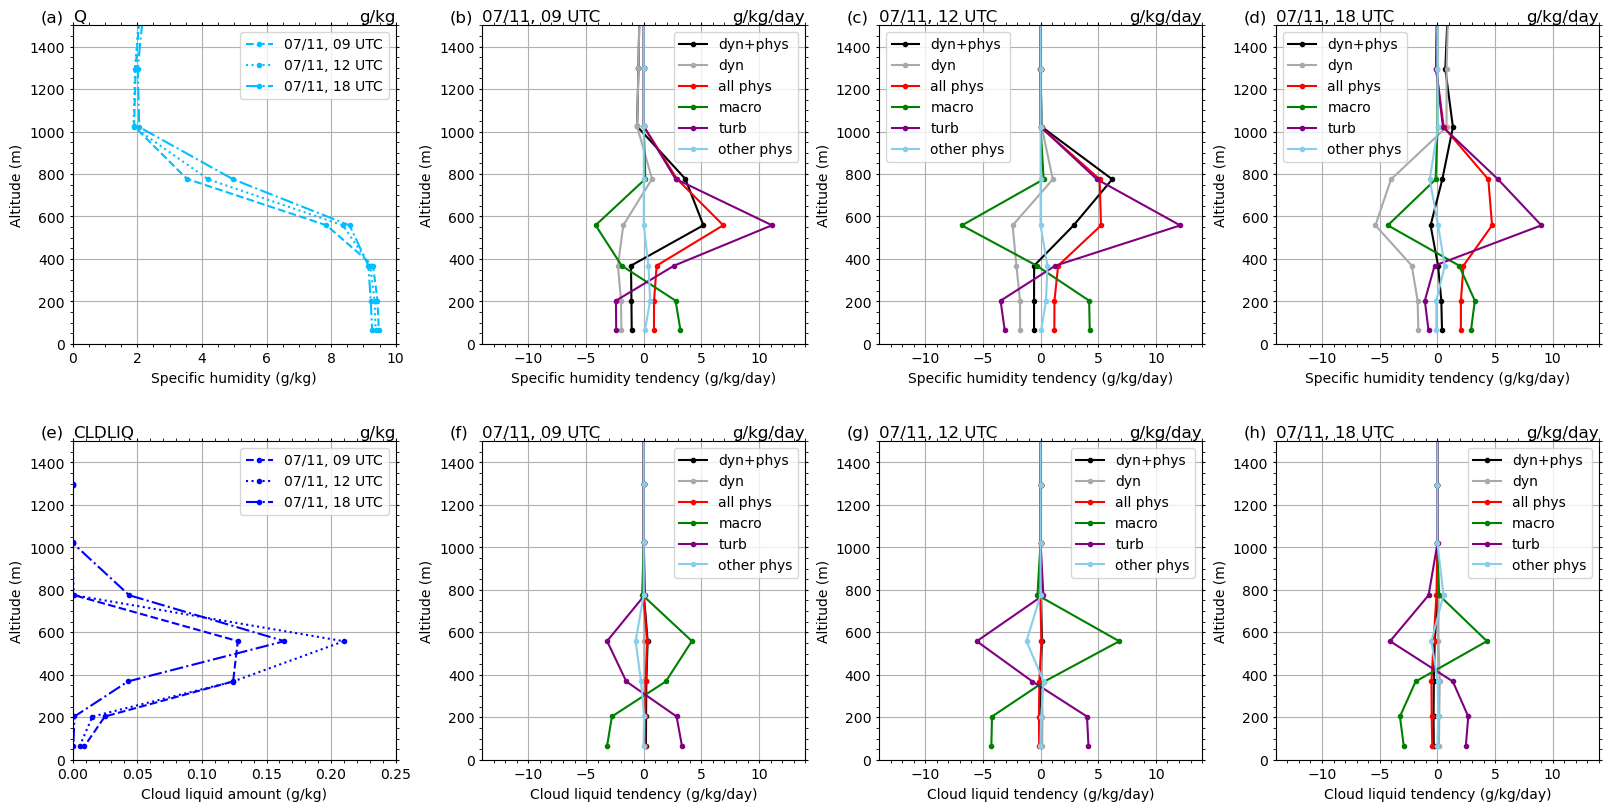

In [237]:
#time_idxes_Nv1tNf = [5, 17, 8]
#time_idxes_Nv1tNf = [27,28,29] 
title = [""]
#ymin_ymax = None
ymin_ymax = (0,1500)

ds_dict_test = ds_dict_tpdf.copy()
yy_dict_test = yy_dict_tpdf.copy()

#time_vert_lines = ["20010710_090000", "20010710_150000", "20010710_210000"]
time_vert_lines = ["20010711_090000", "20010711_120000", "20010711_180000"]
time_idxes_Nv1tNf = get_time_indices_from_strings(ds_dict_test['state'], time_vert_lines)

opt_in_profile_Nv1tNf = {
    "time_idxes_Nv1tNf": time_idxes_Nv1tNf,
    "ds_list": [ds_dict_test] * len(time_idxes_Nv1tNf),
    "yy_list": [yy_dict_test] * len(time_idxes_Nv1tNf),
    "titles": title * len(time_idxes_Nv1tNf),
    #"state_names": ["Ttend"],
    #"var_names": ["PTTEND"],
    "state_names": ["Qtend"],
    #"var_names": ["DQL_budget"],
    "var_names": ["DQL_budget_MA_VD"],
    "xmin_xmax": [(-14, 14)],
    #"xmin_xmax": None,
    "ymin_ymax": [ymin_ymax],
}

opt_in_profile_Nv1t = {
    "ds_1vNt": ds_dict_test['state'], 
    "yy_1vNt": yy_dict_test[lev_select],
    "var_name_1vNt": "CLDLIQ", 
    "time_idx_1vNt": opt_in_profile_Nv1tNf["time_idxes_Nv1tNf"].copy(),
    #"time_idx_1vNt": list(range(24,33,1)),
    #"time_idx_1vNt": list(range(25,30,1)), 
    "title_1vNt": "".join(title),
    #"xmin_xmax_1vNt": None,
    "xmin_xmax_1vNt": (0,0.25),
    "ymin_ymax_1vNt": ymin_ymax,
    #----
    "do_opt_xy": True, 
    "colors": ["blue"] * len(time_idxes_Nv1tNf),
    "linestyles": ["--", ":", "-."],
}

#--- plot 01
opt_in_profile_Nv1t_01 = opt_in_profile_Nv1t.copy()
opt_in_profile_Nv1t_01["ds_1vNt"]=ds_dict_test['state']
opt_in_profile_Nv1t_01["var_name_1vNt"]= "Q"
opt_in_profile_Nv1t_01["colors"] = ["deepskyblue"] * len(time_idxes_Nv1tNf)
opt_in_profile_Nv1t_01["xmin_xmax_1vNt"] = (0,10)

opt_in_profile_Nv1tNf_01 = opt_in_profile_Nv1tNf.copy()
opt_in_profile_Nv1tNf_01["var_names"] = ["DQ_budget_MA_VD"]
#opt_in_profile_Nv1tNf_01["xmin_xmax"] = [(-14, 14)]

#--- plots

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), constrained_layout=True,
                        gridspec_kw={"height_ratios": [1, 1], "hspace": 0.1})
axes_all = axes.flatten()

plot_xy_profile_1vNt_and_Nv1tNf (axes_all[0:4], opt_in_profile_Nv1tNf_01, opt_in_profile_Nv1t_01)
plot_xy_profile_1vNt_and_Nv1tNf (axes_all[4:8], opt_in_profile_Nv1tNf, opt_in_profile_Nv1t)

def add_labels_to_subplots(axes, num_labels=20, fontsize=8):
    # Generate labels from "(a)" to the specified number of labels
    labels = [f"({char})" for char in string.ascii_lowercase[:num_labels]]  

    for i, ax in enumerate(axes):
        if i < len(labels):  # Ensure we don't exceed the number of labels
            ax.text(-0.1, 1.05, labels[i], transform=ax.transAxes, fontsize=12, verticalalignment='top')

add_labels_to_subplots(axes_all)

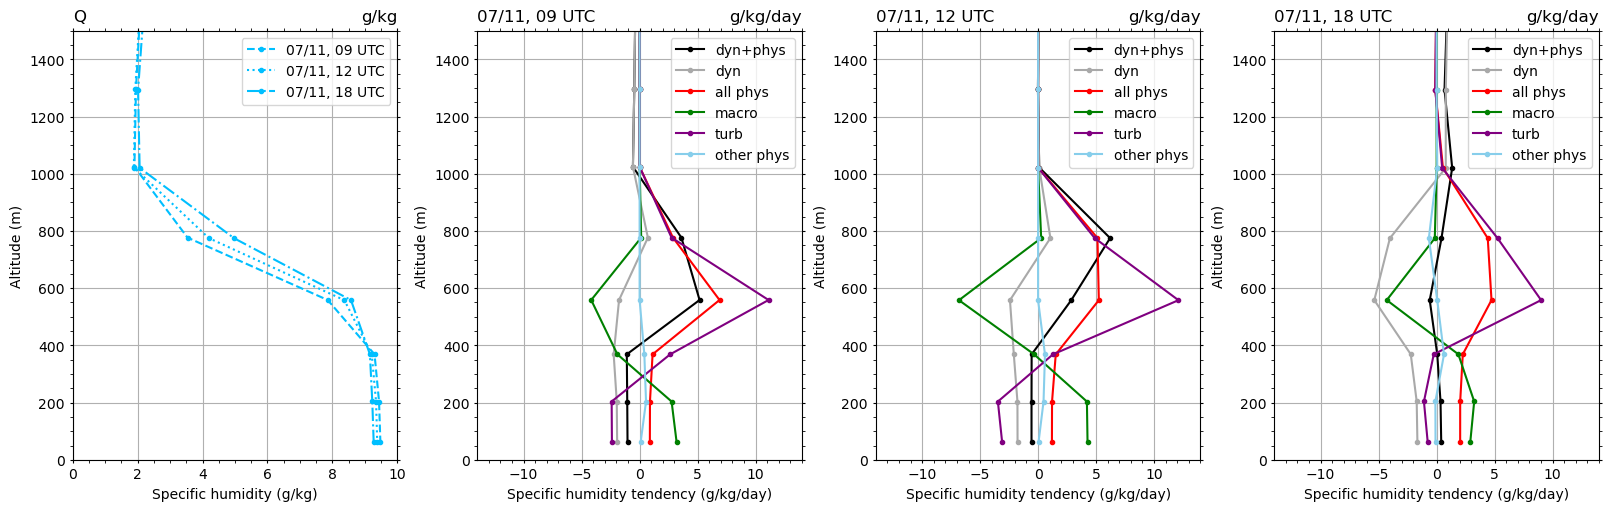

In [238]:
fig, axes = plt.subplots(nrows=1, ncols=len(time_idxes_Nv1tNf)+1, figsize=(16, 5), constrained_layout=True)
plot_xy_profile_1vNt_and_Nv1tNf (axes, opt_in_profile_Nv1tNf_01, opt_in_profile_Nv1t_01)


## plot - time series 

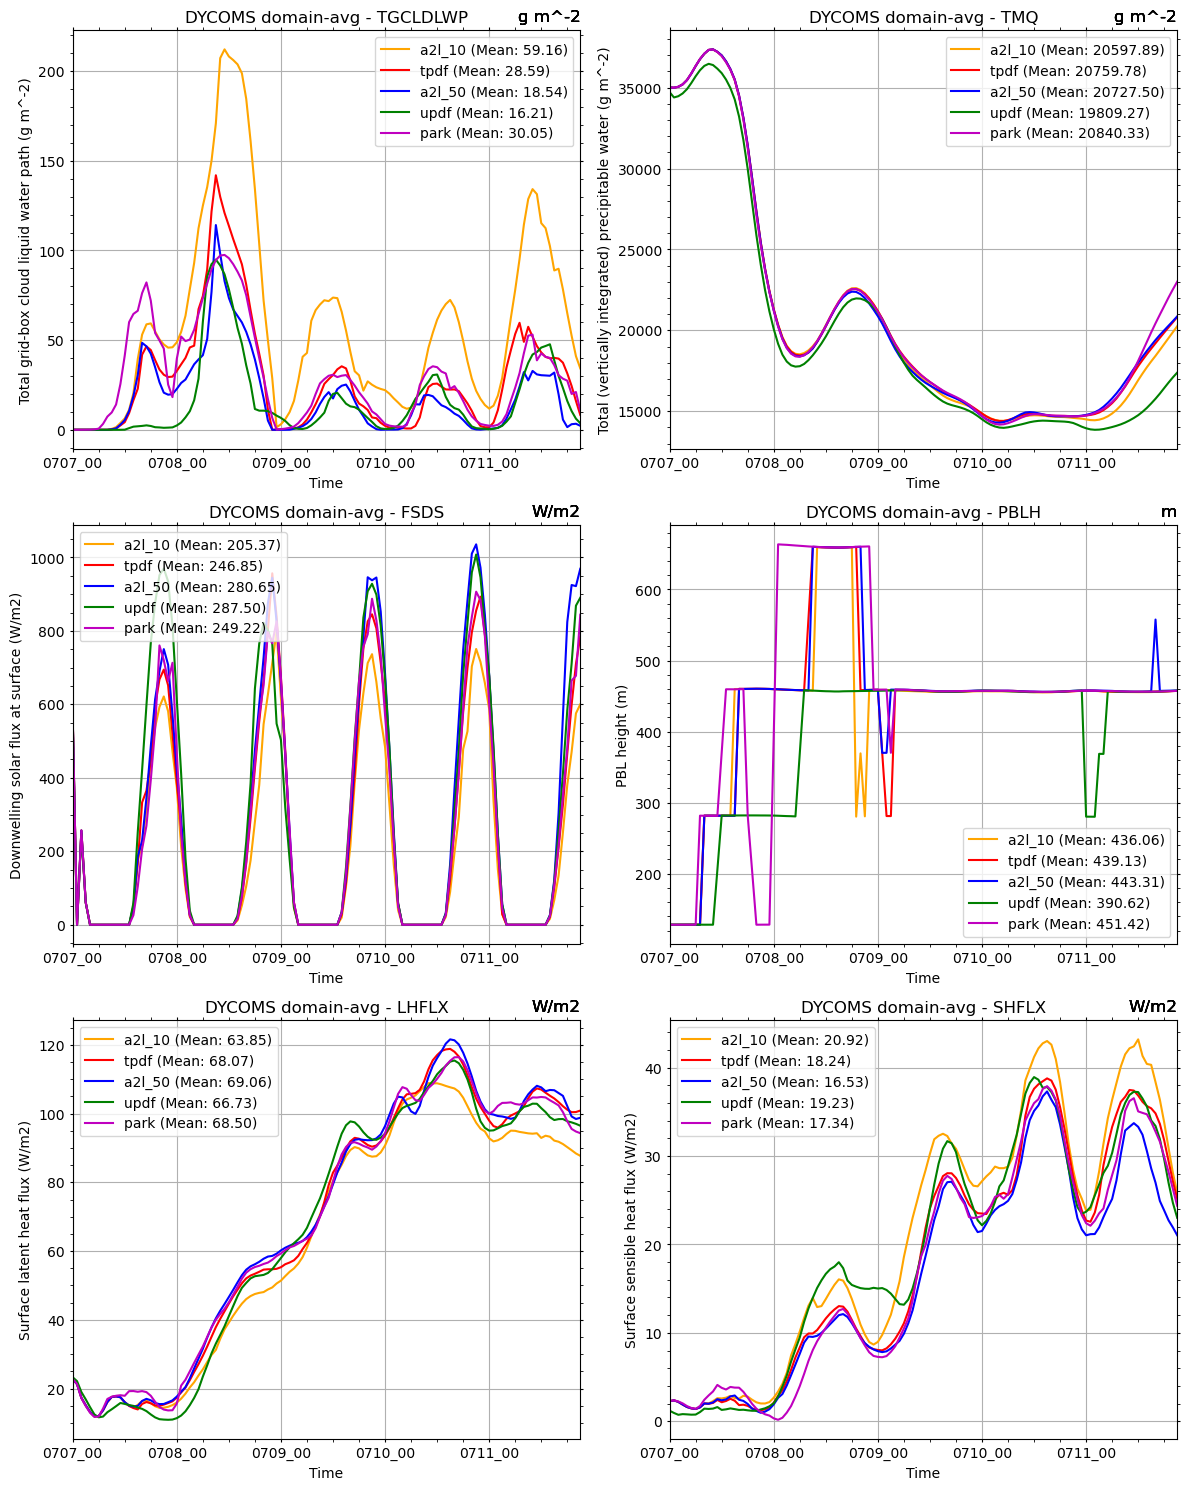

In [59]:
ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50, ds_dict_updf, ds_dict_park]
colors = ["orange", "r", "b", "green", "m"]
labels = ["a2l_10", "tpdf", "a2l_50", "updf", "park"]

var_lists = ["TGCLDLWP", "TMQ", "FSDS", "PBLH", "LHFLX", "SHFLX"]
titles = [f"DYCOMS domain-avg - {var}" for var in var_lists]
plot_xy_series_NvNf(ds_list, var_lists, colors, labels, titles)

## plot - cn time_lev

In [75]:
ds_list = [ds_dict_a2l_10, ds_dict_tpdf, ds_dict_a2l_50]
yy_list = [yy_dict_a2l_10, yy_dict_tpdf, yy_dict_a2l_50]
titles = ["a2l_10", "tpdf", "a2l_50"]

user_settings = {
    "T": {"levels": np.arange(280, 295, 1)},
    "Q": {"cmap": "YlOrRd", "levels": np.arange(1, 10, 0.5)},
    "TTEND_TOT": {"norm_option": "boundary"},
    "MACPDLIQ": {"cmap":"YlOrRd", "levels": np.arange(-15, 15, 1),  "norm_option":"boundary"},
    #"Q": {"cmap": "YlOrRd", "levels": np.arange(1, 12, 1), "norm_option":"boundary"},
    }

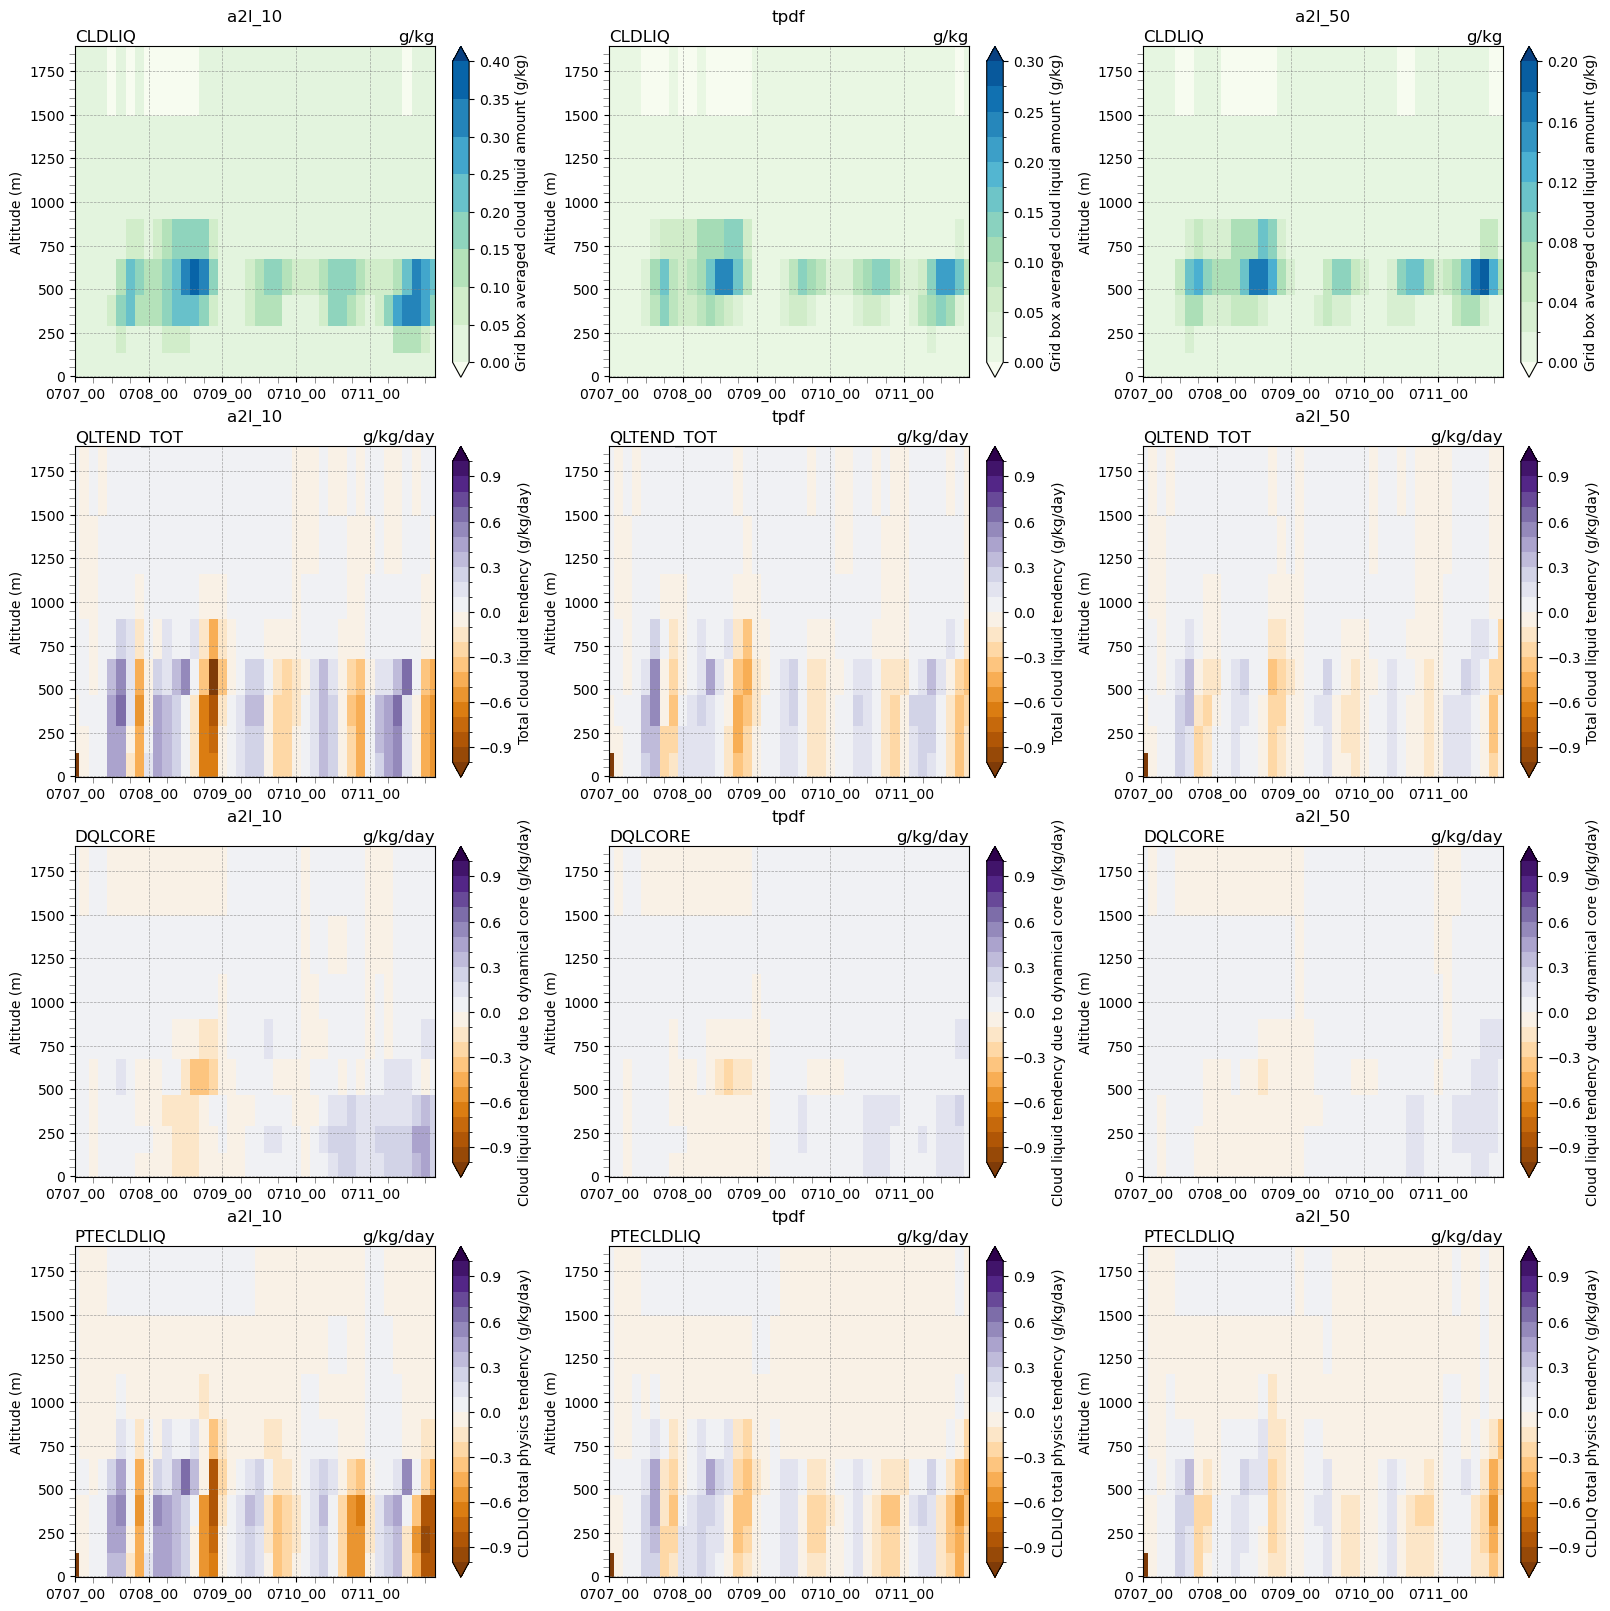

In [77]:
state_names = ["state", "Qtend", "Qtend", "Qtend"]  # Ensure state_names corresponds to each var_name
var_names = ["CLDLIQ", "QLTEND_TOT", "DQLCORE", "PTECLDLIQ"]
    
user_settings = {
    "QLTEND_TOT": {"cmap":"PuOr", "levels": np.arange(-1, 1.1, 0.1),  "norm_option":"boundary"},
}
# Assign the same settings to DQLCORE and PTECLDLIQ
for var in ["DQLCORE", "PTECLDLIQ"]:
    user_settings[var] = user_settings["QLTEND_TOT"].copy()

plot_cn_time_level_NvNf(ds_list, yy_list, titles, var_names, state_names, user_settings=user_settings)

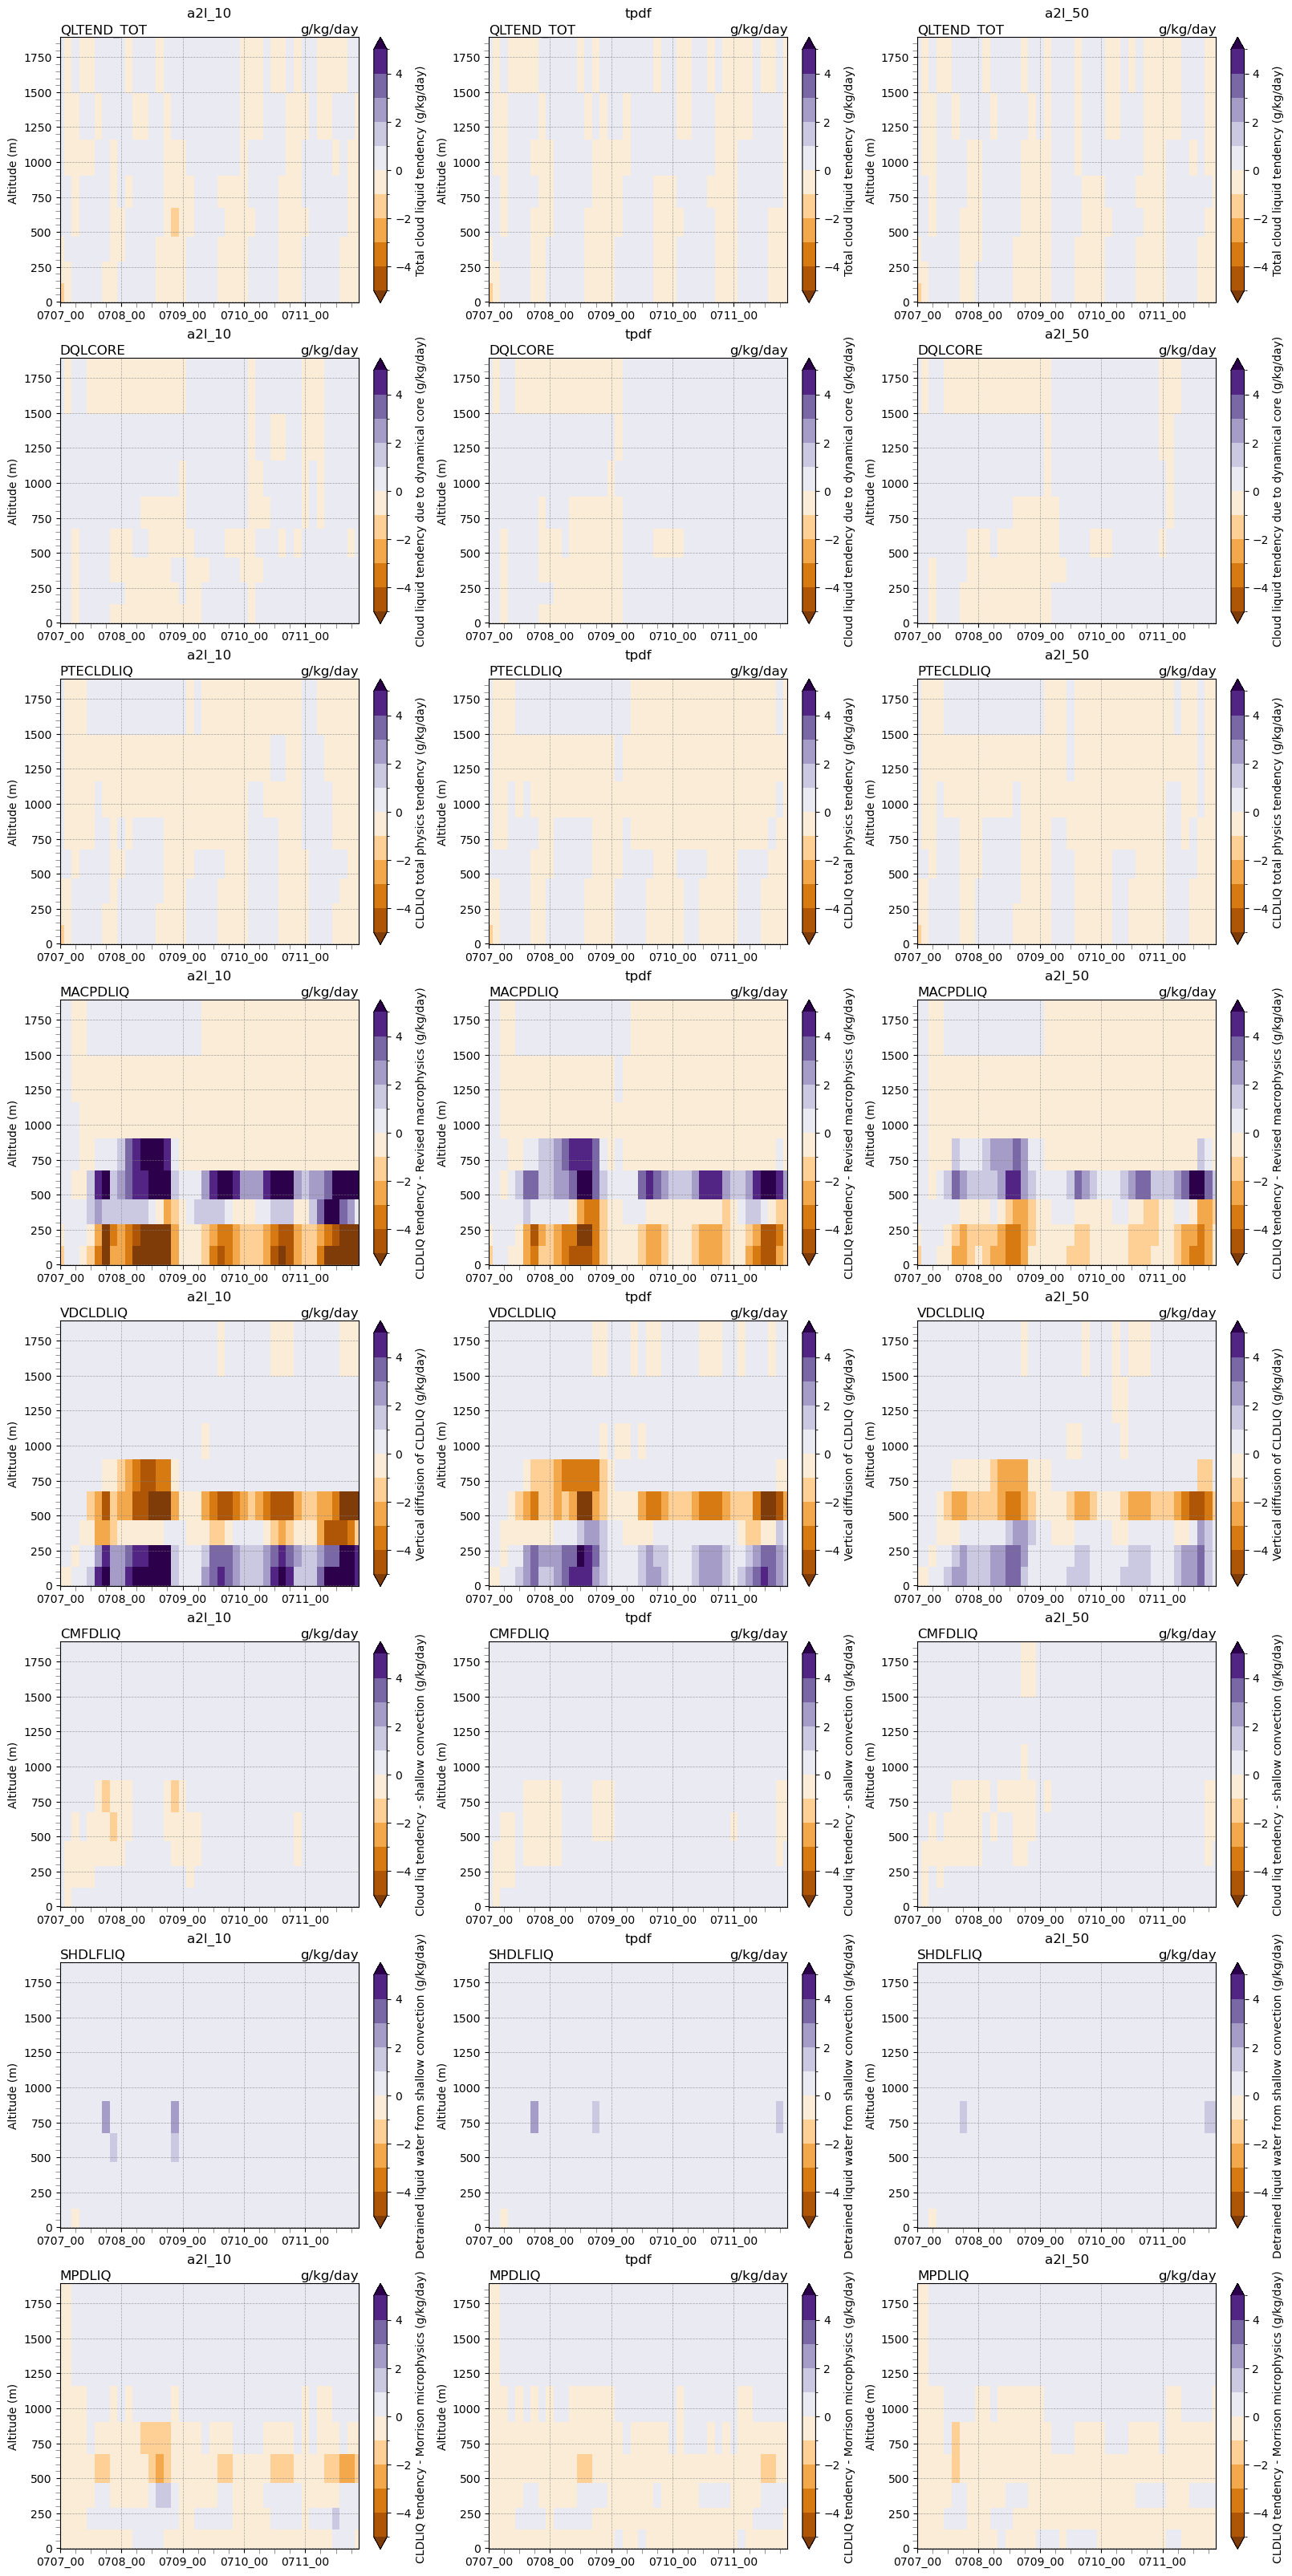

In [78]:
#state_names = ["Qtend", "Qtend", "Qtend"]  # Ensure state_names corresponds to each var_name
var_names = ["QLTEND_TOT", "DQLCORE", "PTECLDLIQ", "MACPDLIQ", "VDCLDLIQ", "CMFDLIQ", "SHDLFLIQ", "MPDLIQ"]
state_names = ["Qtend"] * len(var_names)
    
user_settings = {
    #"QLTEND_TOT": {"cmap":"PuOr", "levels": np.arange(-10, 11, 1),  "norm_option":"boundary"},
    "QLTEND_TOT": {"cmap":"PuOr", "levels": np.arange(-5, 6, 1),  "norm_option":"boundary"},
}
# Assign the same settings to DQLCORE and PTECLDLIQ
#for var in ["DQLCORE", "PTECLDLIQ"]:
for var in var_names:
    user_settings[var] = user_settings["QLTEND_TOT"].copy()

plot_cn_time_level_NvNf(ds_list, yy_list, titles, var_names, state_names, user_settings=user_settings)